# Asteroid orbit optimization with PyGMO - Custom Environment - Actual shape consideration
Copyright (c) 2010-2022, Delft University of Technology. All rights reserved. This file is part of the Tudat. Redistribution  and use in source and binary forms, with or without modification, are permitted exclusively under the terms of the Modified BSD license. You should have received a copy of the license with this file. If not, please or visit: http://tudat.tudelft.nl/LICENSE.

## Objectives
The aim of this tutorial is to illustrate the use of PyGMO to optimize an astrodynamics problem simulated with tudatpy. The problem describes the orbit design around a small body; the [Themis asteroid](https://en.wikipedia.org/wiki/25143_Themis). This example consists of three parts that build on each other to ultimately perform an orbit optimization. The three parts are built up as follows: Custom Environment (this page), [Design Space Exploration](aoo_design_space_exploration.ipynb), and [Optimization](aoo_optimization.ipynb).

**This part of the example is focussed on the creation of a custom environment, using manually defined rotation, ephemeris, gravity field, and shape settings**. A PyGMO compatible Problem class is also created for the next parts of the example. Using this problem class, a propagation is conducted to show a possible trajectory orbiting Themis.


### NOTE

It is assumed that the reader of this tutorial is already familiar with the content of [this basic PyGMO tutorial](https://docs.tudat.space/en/latest/_src_advanced_topics/optimization_pygmo.html). The full PyGMO documentation is available [on this website](https://esa.github.io/pygmo2/index.html). Be careful to read the
correct the documentation webpage (there is also a similar one for previous yet now outdated versions [here](https://esa.github.io/pygmo/index.html); as you can see, they can easily be confused).
PyGMO is the Python counterpart of [PAGMO](https://esa.github.io/pagmo2/index.html).

## Import statements
The required import statements are made here, at the very beginning.

Some standard modules are first loaded. These are `os`, `numpy` and `matplotlib.pyplot`.

Then, the different modules of `tudatpy` that will be used are imported.

Finally, in this example, we also need to import the `pygmo` library.

In [1]:
from IPython.display import HTML
HTML('''
<style>
div.input { display: none; }
div.prompt { display: none; }
</style>
''')

In [2]:
# Load standard modules
import os
import numpy as np
# Uncomment the following to make plots interactive
# %matplotlib widget
from matplotlib import pyplot as plt
from itertools import combinations as comb


# Load tudatpy modules
from tudatpy.data import save2txt
from tudatpy import constants
from tudatpy.interface import spice
from tudatpy.astro import element_conversion
from tudatpy.astro import frame_conversion
from tudatpy.dynamics import environment_setup
from tudatpy.dynamics import propagation_setup
from tudatpy.dynamics import simulator
from tudatpy.util import pareto_optimums

# Load pygmo library
import pygmo as pg

current_dir = os.path.abspath('')

## Creation of Custom Environment

Below a few helper functions are defined that create various custom environment models. These functions are used later in the example to create the simulation


### Themis rotation settings
The first helper function that is setup is `get_Themis_rotation_settings()`. This function can be called to get Themis rotation settings, of type [environment_setup.rotation_model.RotationModelSettings](https://py.api.tudat.space/en/latest/rotation_model.html#tudatpy.dynamics.environment_setup.rotation_model.RotationModelSettings), using a constant angular velocity.

This function only take the name of the body frame of Themis as an input.
In addition, some fixed parameters are defined in this function:

- The orientation of Themis pole, as:
    - The pole declination of -66.3 deg.
    - The pole right ascension 90.53 deg.
    - The meridian fixed at 0 deg.
- The rotation rate of Themis of 712.143 deg/Earth day.

In [3]:
def get_Themis_rotation_settings(Themis_body_frame_name):
    # Definition of initial Themis orientation conditions through the pole orientation
    pole_declination = np.deg2rad(59.8)     # Declination
    pole_right_ascension = np.deg2rad(125.6)  # Right ascension
    meridian_at_epoch = 0.0                   # Meridian

    # Define initial Themis orientation in inertial frame (equatorial plane)
    initial_orientation_j2000 = frame_conversion.inertial_to_body_fixed_rotation_matrix(
        pole_declination, pole_right_ascension, meridian_at_epoch)
    
    # Get initial Themis orientation in inertial frame but in the Ecliptic plane
    initial_orientation_eclipj2000 = np.matmul(spice.compute_rotation_matrix_between_frames(
        "J2000", "ECLIPJ2000", 0.0), initial_orientation_j2000)

    # Manually check the results, if desired
    check_results = False
    if check_results:
        np.set_printoptions(precision=100)
        print(initial_orientation_j2000)
    
        print(initial_orientation_eclipj2000)

    # Compute rotation rate
    # rotation_rate = np.deg2rad(712.143) / constants.JULIAN_DAY
    rotation_period = 8.374187 * 3600.0

    rotation_rate = 2.0 * np.pi / rotation_period

    # Set up rotational model for Themis with constant angular velocity
    return environment_setup.rotation_model.simple(
        "ECLIPJ2000", Themis_body_frame_name, initial_orientation_eclipj2000, 0.0, rotation_rate)

### Themis ephemeris settings
The next helper function defined, `get_Themis_ephemeris_settings()`, that can be used to set the ephemeris of Themis.

The ephemeris for Themis are set using a Keplerian orbit around the Sun. To do this, the initial position at a certain epoch is needed. This position is defined inside the function by the following kepler elements:

- Semi-major axis of $\approx$ 1.324 Astronomical Units ($\approx$ 1.98E+8 km).
- Eccentricity of $\approx$ 0.28.
- Inclination of $\approx$ 1.62 deg.
- Inclination of $\approx$ 1.62 deg.
- Argument of periapsis of $\approx$ 162.8 deg.
- Longitude of ascending node of $\approx$ 69.1 deg.
- Mean anomaly of $\approx$ 187.6 deg.

The only input that this function takes is the gravitational parameter of the Sun, which can be obtained using `spice.get_body_gravitational_parameter("Sun")`.

In [4]:
def get_Themis_ephemeris_settings(sun_gravitational_parameter):
    # Define Themis initial Kepler elements
    Themis_kepler_elements = np.array([
        3.1433 * constants.ASTRONOMICAL_UNIT,
        1.153499536381607E-01,
        np.deg2rad(7.366995500522935E-01),
        np.deg2rad(1.091193307580024E+02),
        np.deg2rad(3.639222711771391E+01),
        np.deg2rad(6.046711080424205E+01)])
    
    # Convert mean anomaly to true anomaly
    Themis_kepler_elements[5] = element_conversion.mean_to_true_anomaly(
        eccentricity=Themis_kepler_elements[1],
        mean_anomaly=Themis_kepler_elements[5])
    
    # Get epoch of initial Kepler elements (in Julian Days) 2025-Dec-12 00:00:00.0000
    kepler_elements_reference_julian_day = 2461021.5
    
    # Sets new reference epoch for Themis ephemerides (different from J2000)
    kepler_elements_reference_epoch = (kepler_elements_reference_julian_day - constants.JULIAN_DAY_ON_J2000) \
                                      * constants.JULIAN_DAY
    
    # Sets the ephemeris model
    return environment_setup.ephemeris.keplerian(
        Themis_kepler_elements,
        kepler_elements_reference_epoch,
        sun_gravitational_parameter,
        "Sun",
        "ECLIPJ2000")

### Themis gravity field settings
The `get_Themis_gravity_field_settings()` helper function can be used to get the gravity field settings of Themis.

It creates a Spherical Harmonics gravity field model expanded up to order 4 and degree 4. Normalized coefficients are hardcoded (see `normalized_cosine_coefficients` and `normalized_sine_coefficients`), as well as the gravitational parameter (2.36). The reference radius and the Themis body fixed frame are to be given as inputs to this function.

In [5]:
def get_Themis_gravity_field_settings(Themis_body_fixed_frame, Themis_radius):
    
    Themis_gravitational_parameter = 3.8e8  # m^3/s^2 — update if you have better value

    # 11x11 matrix → degrees 0-10, orders 0-10
    # Replace these with your actual data
    normalized_cosine_coefficients = np.array([
        [1.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=0
        [4.00437049323391e-10,      -2.00118621702933e-10,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=1
        [-0.0311484302600628, -0.00247282373836691,   -0.00274461339769334,  0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=2
        [-0.00200571383331492, -0.000432075164317321, 0.00194227892499834,0.00137270957639051, 0.0,    0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=3
        [0.00285332640564815,  0.00110182963502399, -0.000735718367676304, 0.000724745021813717, 0.00176998960899976, 0.0,   0.0,      0.0,      0.0,      0.0,      0.0],   # n=4
        [0.000830075337320937,      0.000287519798138761,      -0.000528107896235689,      -0.000867730821110781,      4.79023000648861e-05,      0.000879439295195050,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=5  ← your data
        [-0.000675558666706258,     -0.000205585971704600,      -0.000221135345635429,     -0.000318618655804238,      -0.000888434175048908,      -8.73422067817230e-05,     -0.000661361102590928,      0.0,      0.0,      0.0,      0.0],   # n=6
        [-0.000248341594690701,      -0.000163829109924533,      0.000232085380551457,      0.000258506065235110,      0.000160180230193337,      -0.000286377268939702,      6.77821275261500e-05,     0.000157407479968084,      0.0,      0.0,      0.0],   # n=7
        [0.000335217568650732,      -2.55140470111988e-05,      0.000274255269526383,      4.96324094064370e-05,      0.000342523466493208,     -1.86321450442635e-05,      0.000172675634502437,     9.50587862238274e-05,      0.000145987430976338,      0.0,      0.0],   # n=8
        [6.99720204690460e-05,      8.60097640010565e-05,      -0.000102732485716739,      -4.39268805337316e-05,      -0.000102645709362265,      0.000116936443373915,      -6.33826315277080e-05,      -5.20516633544555e-05,     -3.74472817959948e-05,      2.61212670888696e-05,      0.0],   # n=9
        [-0.000144111884090325,      2.32066521881085e-05,      -0.000126297847367392,      -2.62937726762541e-05,      -0.000124821278562081,      1.97212481561922e-05,      -4.97665457889904e-05,      -3.59202127991231e-05,      -7.28226920211166e-05,      1.23255404885492e-06,      -8.44844997134115e-05],   # n=10
    ])

    normalized_sine_coefficients = np.array([
        # m=0          m=1                        m=2                       m=3                       m=4                       m=5                       m=6                       m=7                       m=8                       m=9                       m=10
        [ 0.0,         0.0,                       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=0
        [ 0.0,        -1.12918257515491e-09,       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=1
        [ 0.0,         0.00107223359971325,       -0.00332663415194219,      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=2
        [ 0.0,        -0.00907886970678376,       -0.000235642226308041,    -0.00453797805800339,       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=3
        [ 0.0,        -0.000236332856522398,       0.000679356889179597,     0.00103902654905862,      -0.00164525397614147,      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=4
        [ 0.0,         0.00311673748224299,       -0.000197902324683847,     0.000723574770295993,     7.12712231701076e-05,      0.000728705277735932,      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=5
        [ 0.0,         9.08985833204355e-05,      -7.81012920836034e-05,    -0.000382933168574949,     0.000417670991355626,     -0.000244616302121161,     -0.000272475519450808,     0.0,                      0.0,                      0.0,                      0.0         ],  # n=6
        [ 0.0,        -0.000726023965052120,      -0.000157289026194778,    -0.000151049434293496,    -1.31229025167918e-05,     -0.000180291881759017,      4.75861083370220e-05,     -0.000466425371326853,     0.0,                      0.0,                      0.0         ],  # n=7
        [ 0.0,        -4.66199482564515e-05,       4.07552978692181e-05,     0.000141144082038173,    -7.01025270851237e-05,      3.48820998708198e-05,      9.78492071833127e-05,      2.78823107064210e-05,     -0.000108013182515871,     0.0,                      0.0         ],  # n=8
        [ 0.0,         0.000177445235331498,       0.000124031343956387,     0.000102169331575207,     3.03402767376233e-05,      0.000131791270134196,      1.21961070494812e-05,      0.000178265283377157,      3.51673248637755e-05,      4.88474288152410e-05,     0.0         ],  # n=9
        [ 0.0,         7.90100853753287e-06,      -1.42280089749264e-05,    -7.29562295080795e-05,     2.77916592967652e-06,     -2.60570209403151e-05,     -2.33055610543032e-05,     -2.66308045112190e-05,      2.55117509946166e-05,     -3.32601179349906e-05,    -3.94450492257997e-06],  # n=10
    ])
    # ← UNCOMMENT this and remove the central() call below
    return environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter=Themis_gravitational_parameter,
        reference_radius=Themis_radius,
        normalized_cosine_coefficients=normalized_cosine_coefficients,
        normalized_sine_coefficients=normalized_sine_coefficients,
        associated_reference_frame=Themis_body_fixed_frame)

    # ← REMOVE this line (was placeholder, ignores all SH structure)
    # return environment_setup.gravity_field.central(
    #     gravitational_parameter=Themis_gravitational_parameter)

### Themis shape settings
The next helper function defined, `get_Themis_shape_settings()` return the shape settings object for Themis. It uses a simple spherical model, and take the radius of Themis as input.

In [6]:
def get_Themis_shape_settings(vertices, faces):
    """
    Polyhedral shape model.
    vertices : (N, 3) float64 array — Cartesian coordinates in metres
    faces    : (M, 3) int32 array  — 0-based vertex indices, CCW from outside
    """
    # ── Type enforcement — Tudat is strict about these dtypes ────────────────
    vertices_f64 = np.asarray(vertices, dtype=np.float64)   # must be float64
    faces_i32    = np.asarray(faces,    dtype=np.int32)      # must be int32 ← key fix

    # ── Winding order check — normals must point outward ─────────────────────
    centroid = vertices_f64.mean(axis=0)
    n_inward = 0
    for f in faces_i32[:10]:                      # spot-check first 10 faces
        v0, v1, v2 = vertices_f64[f[0]], vertices_f64[f[1]], vertices_f64[f[2]]
        normal  = np.cross(v1 - v0, v2 - v0)
        if np.dot(normal, v0 - centroid) < 0:
            n_inward += 1
    if n_inward > 5:                              # majority inward → flip all
        print("[SHAPE] ⚠  Winding order is inward — flipping all faces")
        faces_i32 = faces_i32[:, ::-1]
    else:
        print("[SHAPE] ✓  Winding order looks correct (outward normals)")

    print(f"[SHAPE] Vertices: {vertices_f64.shape}  dtype={vertices_f64.dtype}")
    print(f"[SHAPE] Faces:    {faces_i32.shape}     dtype={faces_i32.dtype}")

    return environment_setup.shape.polyhedron(
        vertices_coordinates        = vertices_f64,   # ← correct kwarg name
        vertices_defining_each_facet= faces_i32,      # ← correct kwarg name
        compute_altitude_with_sign  = True,           # >0 above surface, <0 below
        just_compute_distance_to_vertices = False     # full accuracy (slower)
    )

### Simulation bodies
Next, the `create_simulation_bodies()` function is setup, that returns an [environment.SystemOfBodies](https://py.api.tudat.space/en/latest/environment.html#tudatpy.dynamics.environment.SystemOfBodies) object. This object contains all the body settings and body objects required by the simulation. Only one input is required to this function: the radius of Themis.

Moreover, in the system of bodies that is returned, a `Spacecraft` body is included, with a mass of 400kg, and a radiation pressure interface. This body is the one for which an orbit is to be optimised around Themis.

In [7]:
def create_simulation_bodies(Themis_radius, vertices, faces):
    Themis_body_frame_name = "Themis_Frame"
    bodies_to_create = ["Sun", "Earth", "Jupiter", "Saturn", "Mars"]

    body_settings = environment_setup.get_default_body_settings(
        bodies_to_create, "SSB", "ECLIPJ2000")

    body_settings.add_empty_settings("Themis")

    # Gravity: always SH 10x10
    body_settings.get("Themis").gravity_field_settings = \
        get_Themis_gravity_field_settings(Themis_body_frame_name, Themis_radius)

    body_settings.get("Themis").rotation_model_settings = \
        get_Themis_rotation_settings(Themis_body_frame_name)

    body_settings.get("Themis").ephemeris_settings = \
        get_Themis_ephemeris_settings(spice.get_body_gravitational_parameter('Sun'))

    # Shape: polyhedral — used for altitude computation and radiation occulting
    body_settings.get("Themis").shape_settings = \
        get_Themis_shape_settings(vertices, faces)

    ### VEHICLE ###
    body_settings.add_empty_settings("Spacecraft")
    body_settings.get("Spacecraft").constant_mass = 986
    reference_area_radiation = 65 + 2.4 * 2.2
    radiation_pressure_coefficient = 1.2
    occulting_bodies_dict = {"Sun": ["Themis"]}
    vehicle_target_settings = environment_setup.radiation_pressure.cannonball_radiation_target(
        reference_area_radiation, radiation_pressure_coefficient, occulting_bodies_dict)
    body_settings.get("Spacecraft").radiation_pressure_target_settings = vehicle_target_settings

    return environment_setup.create_system_of_bodies(body_settings)

### Acceleration models
The `get_acceleration_models()` helper function returns the acceleration models to be used during the astrodynamic simulation. The following accelerations are included:

- Gravitational acceleration modelled as a Point Mass from the Sun, Jupiter, Saturn, Mars, and the Earth.
- Gravitational acceleration modelled as Spherical Harmonics up to degree and order 4 from Themis.
- Radiation pressure from the Sun using a simplified cannonball model.

This function takes as input the list of bodies that will be propagated, the list of central bodies related to the propagated bodies, and the system of bodies used.

In [8]:
def get_acceleration_models(bodies_to_propagate, central_bodies, bodies):
    # Gravity is ALWAYS spherical harmonic — polyhedral gravity doesn't exist in Tudat
    # The polyhedral SHAPE model is separate and handles altitude/occultation
    accelerations_settings_spacecraft = dict(
        Sun     = [ propagation_setup.acceleration.radiation_pressure(),
                    propagation_setup.acceleration.point_mass_gravity() ],
        Themis  = [ propagation_setup.acceleration.spherical_harmonic_gravity(10, 10) ],  # ← always SH
        Jupiter = [ propagation_setup.acceleration.point_mass_gravity() ],
        Saturn  = [ propagation_setup.acceleration.point_mass_gravity() ],
        Mars    = [ propagation_setup.acceleration.point_mass_gravity() ],
        Earth   = [ propagation_setup.acceleration.point_mass_gravity() ]
    )

    acceleration_settings = {"Spacecraft": accelerations_settings_spacecraft}

    return propagation_setup.create_acceleration_models(
        bodies,
        acceleration_settings,
        bodies_to_propagate,
        central_bodies)

### Termination settings
The termination settings for the simulation are defined by the `get_termination_settings()` helper.

Nominally, the simulation terminates when a final epoch is reached. However, this can happen in advance if the
spacecraft breaks out of the predefined altitude range.
This is defined by the four inputs that this helper function takes, related to the mission timing and the mission altitude range.

In [9]:
def get_termination_settings(mission_initial_time, mission_duration,
                              minimum_altitude, maximum_altitude, Themis_radius):
    """
    Termination based on TRUE altitude above shape model surface.
    Works for both spherical and polyhedral shape models automatically.
    minimum_altitude / maximum_altitude in metres above surface.
    No Themis_radius offset needed — Tudat handles it via shape model.
    """
    # Time termination
    time_termination = propagation_setup.propagator.time_termination(
        mission_initial_time + mission_duration,
        terminate_exactly_on_final_condition=False
    )

    # Upper altitude limit — terminate if spacecraft goes too high
    upper_termination = propagation_setup.propagator.dependent_variable_termination(
        dependent_variable_settings=propagation_setup.dependent_variable.altitude(
            'Spacecraft', 'Themis'               # ← altitude above shape surface
        ),
        limit_value=maximum_altitude,             # metres above surface directly
        use_as_lower_limit=False,                 # terminate if altitude > max
        terminate_exactly_on_final_condition=False
    )

    # Lower altitude limit — terminate if spacecraft gets too close (crash risk)
    lower_termination = propagation_setup.propagator.dependent_variable_termination(
        dependent_variable_settings=propagation_setup.dependent_variable.altitude(
            'Spacecraft', 'Themis'
        ),
        limit_value=minimum_altitude,             # metres above surface directly
        use_as_lower_limit=True,                  # terminate if altitude < min
        terminate_exactly_on_final_condition=False
    )

    return propagation_setup.propagator.hybrid_termination(
        [time_termination, upper_termination, lower_termination],
        fulfill_single_condition=True
    )

### Dependent variables to save
Finally, the `get_dependent_variables_to_save()` helper function returns a pre-defined list of dependent variables to save during the propagation, alongside the propagated state. This function can be expanded, but contains by default only the position of the spacecraft with respect to the Themis asteroid expressed in spherical coordinates.

In [10]:
def get_dependent_variables_to_save():
    return [
        # col 0,1,2 → r, lat, lon in body-fixed spherical coords
        propagation_setup.dependent_variable.central_body_fixed_spherical_position(
            "Spacecraft", "Themis"
        ),
        # col 3,4,5,6,7,8 → a, e, i, AoP, RAAN, TA
        propagation_setup.dependent_variable.keplerian_state(
            "Spacecraft", "Themis"
        ),
        # col 9 → true altitude above shape surface (polyhedral or spherical)
        propagation_setup.dependent_variable.altitude(
            "Spacecraft", "Themis"               # ← this is the key new one
        ),
        # col 10 → distance from CoM (keep for reference/debugging)
        propagation_setup.dependent_variable.relative_distance(
            "Spacecraft", "Themis"
        ),
    ]
    # Index reference:
    # dep_arr[:, 0]  = distance from CoM (spherical r)  [m]
    # dep_arr[:, 1]  = latitude                         [rad]
    # dep_arr[:, 2]  = longitude                        [rad]
    # dep_arr[:, 3]  = semi-major axis                  [m]
    # dep_arr[:, 4]  = eccentricity                     [-]
    # dep_arr[:, 5]  = inclination                      [rad]
    # dep_arr[:, 6]  = argument of periapsis            [rad]
    # dep_arr[:, 7]  = RAAN                             [rad]
    # dep_arr[:, 8]  = true anomaly                     [rad]
    # dep_arr[:, 9]  = TRUE altitude above surface      [m]  ← new
    # dep_arr[:, 10] = distance from CoM                [m]

## Optimisation problem formulation 
The optimisation problem can now be defined. This has to be done in a class that is compatible to what the PyGMO library can expect from this User Defined Problem (UDP). See [this page](https://esa.github.io/pygmo2/problem.html#pygmo.problem) from the PyGMO documentation as a reference. In this example, this class is called `AsteroidOrbitProblem`.

The `AsteroidOrbitProblem.__init__()` method is used to setup the problem. Most importantly, many problem-related objects are saved through it: the system of bodies, the propagator settings, the parameters that will later be used for the termination settings, and the design variables boundaries. The input arguments that refer to functions are defined using a lambda function. While this seems unnecessary, it is **essential**: PyGMO internally pickles its user defined objects and some objects including the ones here cannot be pickled properly without using lambda functions.

Then, the `AsteroidOrbitProblem.get_bounds()` function is used by PyGMO to define the search space. This function returns the boundaries of each design variable, as defined in the [pygmo.problem.get_bounds](https://esa.github.io/pygmo2/problem.html#pygmo.problem.get_bounds) documentation.

The `AsteroidOrbitProblem.get_nobj()` function is also used by PyGMO. It returns the number of objectives in the problem, in this case 2.

The last function used by PyGMO is `AsteroidOrbitProblem.fitness()`. As mentioned in the [pygmo.problem.fitness](https://esa.github.io/pygmo2/problem.html#pygmo.problem.fitness) documentation, PyGMO will input a given set of design variable to this function, that is expected to return a score associated with them. This is thus the cost function of the problem. In this case, this `AsteroidOrbitProblem.fitness()` runs a simulation using TudatPy based on the orbital elements that PyGMO inputs as design variables. Then, the score relative to the two optimisation objectives is computed and returned. Note that, in PyGMO, this fitness function will always be **minimised**. To **maximise** objectives instead, the fitness that is returned will have to be for instance inversed. This is why, because we want to maximise the coverage, the fitness for this objective is computed as the inverse of the mean latitudes. If the mean of the latitudes is high, the coverage is high, which is closer to the optimum. Because this better value is higher than worse values, we return the fitness as the inverse of the mean latitudes.

One more function is included, `AsteroidOrbitProblem.get_last_run_dynamics_simulator()`. This allows to get the dynamic simulator of the last simulation that was run in the problem.

In [11]:
class AsteroidOrbitProblem:
    
    def __init__(self,
                 bodies,
                 propagator_settings,
                 mission_initial_time,
                 mission_duration,
                 design_variable_lower_boundaries,
                 design_variable_upper_boundaries):
        
        # Sets input arguments as lambda function attributes
        # NOTE: this is done so that the class is "pickable", i.e., can be serialized by pygmo
        self.bodies_function = lambda: bodies
        self.propagator_settings_function = lambda: propagator_settings
        
        # Initialize empty dynamics simulator
        self.dynamics_simulator_function = lambda: None
        
        # Set other input arguments as regular attributes
        self.mission_initial_time = mission_initial_time
        self.mission_duration = mission_duration
        self.mission_final_time = mission_initial_time + mission_duration
        self.design_variable_lower_boundaries = design_variable_lower_boundaries
        self.design_variable_upper_boundaries = design_variable_upper_boundaries

    def get_bounds(self):
        return (list(self.design_variable_lower_boundaries), list(self.design_variable_upper_boundaries))

    def get_nobj(self):
        return 2

    def fitness(self,
                orbit_parameters):
        # Retrieves system of bodies
        current_bodies = self.bodies_function()
        
        # Retrieves Themis gravitational parameter
        Themis_gravitational_parameter = current_bodies.get("Themis").gravitational_parameter
        
        # Reset the initial state from the design variable vector
        new_initial_state = element_conversion.keplerian_to_cartesian_elementwise(
            gravitational_parameter=Themis_gravitational_parameter,
            semi_major_axis=orbit_parameters[0],
            eccentricity=orbit_parameters[1],
            inclination=np.deg2rad(orbit_parameters[2]),
            argument_of_periapsis=np.deg2rad(235.7),
            longitude_of_ascending_node=np.deg2rad(orbit_parameters[3]),
            true_anomaly=np.deg2rad(139.87))
        
        # Retrieves propagator settings object
        propagator_settings = self.propagator_settings_function()
        
        # Reset the initial state
        propagator_settings.initial_states = new_initial_state

        # Propagate orbit
        dynamics_simulator = simulator.create_dynamics_simulator(current_bodies,
                                                                        propagator_settings)
        # Update dynamics simulator function
        self.dynamics_simulator_function = lambda: dynamics_simulator
       
        # --- DEBUG BLOCK START ---
        state_hist = dynamics_simulator.propagation_results.state_history
        dep_var_hist = dynamics_simulator.propagation_results.dependent_variable_history

        print(f"\n{'='*50}")
        print(f"[DEBUG] Orbit params: a={orbit_parameters[0]:.1f} m, e={orbit_parameters[1]:.4f}, "
              f"i={orbit_parameters[2]:.2f} deg, RAAN={orbit_parameters[3]:.2f} deg")

        print(f"[DEBUG] Propagation steps recorded: {len(state_hist)}")

        if len(state_hist) > 0:
            t_start = min(state_hist.keys())
            t_end   = max(state_hist.keys())
            duration_achieved = t_end - t_start
            print(f"[DEBUG] Time propagated: {duration_achieved:.2f} s  "
                  f"({duration_achieved / 86400:.4f} days)")
            print(f"[DEBUG] Mission duration target: {self.mission_duration / 86400:.2f} days")

            if duration_achieved < self.mission_duration * 0.999:
                # Terminated early — figure out why
                # Inside AsteroidOrbitProblem.fitness(), replace the debug block:

                if len(dep_var_hist) > 0:
                    dep_arr = np.vstack(list(dep_var_hist.values()))
                    final_altitude = dep_arr[-1, 9]          # col 9 = true altitude [m]
                    final_dist_com = dep_arr[-1, 10]         # col 10 = CoM distance [m]

                    print(f"[DEBUG] *** EARLY TERMINATION ***")
                    print(f"[DEBUG] Final altitude above surface: {final_altitude:.2f} m "
                          f"({final_altitude/1000:.3f} km)")
                    print(f"[DEBUG] Final distance from CoM:      {final_dist_com:.2f} m "
                          f"({final_dist_com/1000:.3f} km)")

                    if final_altitude < minimum_altitude:
                        print(f"[DEBUG] → CRASHED (below {minimum_altitude/1e3:.1f} km altitude)")
                    elif final_altitude > maximum_altitude:
                        print(f"[DEBUG] → ESCAPED (above {maximum_altitude/1e3:.1f} km altitude)")
                    else:
                        print(f"[DEBUG] → Reason unclear; check termination_details")
                else:
                    print(f"[DEBUG]   *** dep_var_hist is EMPTY — likely terminated in step 1 ***")
            else:
                print(f"[DEBUG] Full mission duration completed ✓")
        else:
            print(f"[DEBUG] *** state_history is EMPTY — propagation failed at t=0 ***")

        # Termination details (tudat exposes this)
        try:
            term = dynamics_simulator.propagation_results.termination_details
            print(f"[DEBUG] Termination details: {term}")
        except Exception as ex:
            print(f"[DEBUG] Could not retrieve termination_details: {ex}")

        print(f"{'='*50}\n")
    # --- DEBUG BLOCK END ---
        # Retrieve dependent variable history
        dependent_variables = dynamics_simulator.propagation_results.dependent_variable_history
        dependent_variables_list = np.vstack(list(dependent_variables.values()))
        
        # In fitness(), replace the penalty check:

# OLD (using CoM distance):
# if max(dep_var_history.keys()) < self.mission_final_time:

# NEW (same logic, but update debug to use altitude):
        current_penalty = 0.0
        if max(dynamics_simulator.propagation_results.dependent_variable_history.keys()) \
                < self.mission_final_time:
            current_penalty = 1.0E2

# Pull altitude for fitness computation (col 9)
        altitude = dependent_variables_list[:, 9]         # true altitude [m]
        latitudes = dependent_variables_list[:, 1]        # latitude [rad]
        mean_latitude = np.mean(np.absolute(latitudes))
        current_fitness = 1.0 / mean_latitude

        return [current_fitness + current_penalty,
                np.mean(altitude) + current_penalty * 1.0E3]   # mean altitude as 2nd objective

    def get_last_run_dynamics_simulator(self):
        return self.dynamics_simulator_function()

### Setup orbital simulation
Before running the optimisation, some aspect of the orbital simulation around Themis still need to be setup.
Most importantly, the simulation bodies, acceleration models, integrator settings, and propagator settings, all have to be defined. To do so, the helpers that were defined above are used.

#### Simulation settings
The simulation settings are first defined.

The SPICE kernels are loaded, so that we can access the gravitational parameter of the Sun in the `create_simulation_bodies()` function.

The definition of the termination parameters follows, with a maximum mission duration of 5 Earth days. The altitude range above Themis is also defined between 150 meters and 5 km.

Follows the definition of the design variable range, that PyGMO will use during the optimisation. This range is as follows:

- Initial semi-major axis between 300 and 2000 meters.
- Initial eccentricity between 0 and 0.3.
- Initial inclination between 0 and 180 deg.
- Initial longitude of the ascending node between 0 and 360 deg.
 
The system of bodies is then setup using the `create_simulation_bodies()` helper, and a radius for Themis of 161.915 meters.

Finally, the acceleration models are setup using the `get_acceleration_models()` helper.

In [12]:
# ── Load shape data ───────────────────────────────────────────────────────────
themis_vertices = np.loadtxt(r'C:\Users\RAJAT GUPTA\Downloads\themis_vertices.csv', delimiter=',')   # (402, 3) metres
themis_faces    = np.loadtxt(r'C:\Users\RAJAT GUPTA\Downloads\themis_faces.csv',    delimiter=',', dtype=int)  # (800, 3)

# ── Mission settings ──────────────────────────────────────────────────────────
spice.load_standard_kernels()
from tudatpy.astro.time_representation import DateTime
mission_initial_time = DateTime(2046, 12, 27, 00, 40, 56).epoch()
mission_duration     = 140.0 * constants.JULIAN_DAY

# ── Step 1: center the mesh if needed ────────────────────────────────────────
centroid = themis_vertices.mean(axis=0)
offset_km = np.linalg.norm(centroid) / 1e3
print(f"Centroid offset: {offset_km:.3f} km")

if offset_km > 1.0:   # more than 1 km offset → re-center
    print("Re-centering mesh to CoM...")
    themis_vertices = themis_vertices - centroid

# ── Step 2: compute true radii ────────────────────────────────────────────────
r_all = np.linalg.norm(themis_vertices, axis=1)

mean_themis_radius_m = r_all.mean()
min_themis_radius_m  = r_all.min()
max_themis_radius_m  = r_all.max()

print(f"Mean radius: {mean_themis_radius_m/1e3:.3f} km")
print(f"Min  radius: {min_themis_radius_m/1e3:.3f} km")
print(f"Max  radius: {max_themis_radius_m/1e3:.3f} km")


# ── Step 3: update Themis_radius to mesh-derived value ───────────────────────
Themis_radius = 99*1000    # replaces the hardcoded 99*1000
print(f"\nThemis_radius updated: {Themis_radius/1e3:.3f} km  (was 99.000 km)")


# ── Altitude-based termination limits ─────────────────────────────────────────
minimum_altitude = 1.0e3    # 10 km above surface
maximum_altitude = 550.0e3   # 550 km above surface

# ── Design variable bounds ────────────────────────────────────────────────────
design_variable_lb = (255000.0,  0.0, 0.0,   0.0)
design_variable_ub = (285000.0, 0.3, 180.0, 360.0)

# ── Build environment ─────────────────────────────────────────────────────────
bodies = create_simulation_bodies(Themis_radius,
                                   vertices=themis_vertices,
                                   faces=themis_faces)

bodies_to_propagate = ["Spacecraft"]
central_bodies      = ["Themis"]
acceleration_models = get_acceleration_models(bodies_to_propagate, central_bodies, bodies)

# ── Termination and dependent variables ───────────────────────────────────────
dependent_variables_to_save = get_dependent_variables_to_save()
termination_settings = get_termination_settings(
    mission_initial_time, mission_duration,
    minimum_altitude, maximum_altitude, Themis_radius
)

Centroid offset: 6.694 km
Re-centering mesh to CoM...
Mean radius: 115.893 km
Min  radius: 85.714 km
Max  radius: 152.716 km

Themis_radius updated: 99.000 km  (was 99.000 km)
[SHAPE] ✓  Winding order looks correct (outward normals)
[SHAPE] Vertices: (402, 3)  dtype=float64
[SHAPE] Faces:    (800, 3)     dtype=int32


#### Dependent variables, termination settings, and orbit parameters
To define the propagator settings in the subsequent sections, we first call the `get_dependent_variables_to_save()` and `get_termination_settings()` helpers to define the dependent variables and termination settings.

The `orbit_parameters` list is defined from a `final_population.dat` file from the optimization. These values are not crucial, but do help for a 'relatively' stable orbit.

In [13]:
# Define list of dependent variables to save
dependent_variables_to_save = get_dependent_variables_to_save()

# Create propagation settings
termination_settings = get_termination_settings(
    mission_initial_time,
    mission_duration,
    minimum_altitude,       # ← metres above surface, that's it
    maximum_altitude,
    Themis_radius
)

orbit_parameters = [1.20940330e+03, 2.61526215e-01, 7.53126558e+01, 2.60280587e+02]

#### Integrator and Propagator settings
Let's now define the integrator settings. In this case, a variable step integration scheme is used, with the followings:

- RKF7(8) coefficient set.
- Initial time step of 1 sec.
- Minimum and maximum time steps of 1E-6 sec and 1 Earth day.
- Relative and absolute error tolerances of 1E-8.

Then, we define pure translational propagation settings with a Cowell propagator. The initial state is set to 0 for both the position and the velocity. This is because the initial state will later be changed in the `AsteroidOrbitProblem.fitness()` function during the optimisation.

In [14]:
# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    initial_time_step=1.0,
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78,
    minimum_step_size=1.0E-6,
    maximum_step_size=constants.JULIAN_DAY,
    relative_error_tolerance=1.0E-8,
    absolute_error_tolerance=1.0E-8)

# Get current propagator, and define translational state propagation settings
propagator = propagation_setup.propagator.cowell
# Define propagation settings
initial_state = np.zeros(6)
propagator_settings = propagation_setup.propagator.translational(central_bodies,
                                                                         acceleration_models,
                                                                         bodies_to_propagate,
                                                                         initial_state,
                                                                         mission_initial_time,
                                                                         integrator_settings,
                                                                         termination_settings,
                                                                         propagator,
                                                                         dependent_variables_to_save)

## Propagating Orbit

To finalise this part of the example, a simple orbit is propagated to show the plausibility of the simulation. The PyGMO compatible problem class is created, after which the fitness function is called which creates the dynamics simulator and subsequently returns the data that can be used for post-processing.

The 4 design variables are:

- initial values of the semi-major axis.
- initial eccentricity.
- initial inclination.
- initial longitude of the ascending node.

In [15]:
orbitProblem = AsteroidOrbitProblem(bodies,
                                    propagator_settings,
                                    mission_initial_time,
                                    mission_duration,
                                    design_variable_lb,
                                    design_variable_ub)
# design_variable_vector = np.array([1.20940330e+03, 2.61526215e-01, 7.53126558e+01, 2.60280587e+02])
design_variable_vector = np.array([
    139990.0,
    0.00458,
    154.10,
    356.68
])
orbitProblem.fitness(design_variable_vector)


[DEBUG] Orbit params: a=139990.0 m, e=0.0046, i=154.10 deg, RAAN=356.68 deg
[DEBUG] Propagation steps recorded: 17887
[DEBUG] Time propagated: 12096250.93 s  (140.0029 days)
[DEBUG] Mission duration target: 140.00 days
[DEBUG] Full mission duration completed ✓
[DEBUG] Termination details: <tudatpy.kernel.dynamics.propagation.PropagationTerminationDetailsFromHybridCondition object at 0x000001E4D7813770>



[2.5001763515376414, 23204.594929700073]

### Visualizing orbit
With a little bit of post-processing, the orbit can be plotted. You can see that with only 2 full orbits that the trajectory is already very perturbed. This has to do with all the perturbations that are in the model, which poses a challenge for the optimization in the next two parts of the example.

Themis radius — mean : 115.893 km
Themis radius — min  : 85.714 km
Themis radius — max  : 152.716 km
Interpolating surface radius along trajectory...
Done.


C:\Users\RAJAT GUPTA\AppData\Local\Temp\ipykernel_22804\3441433747.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


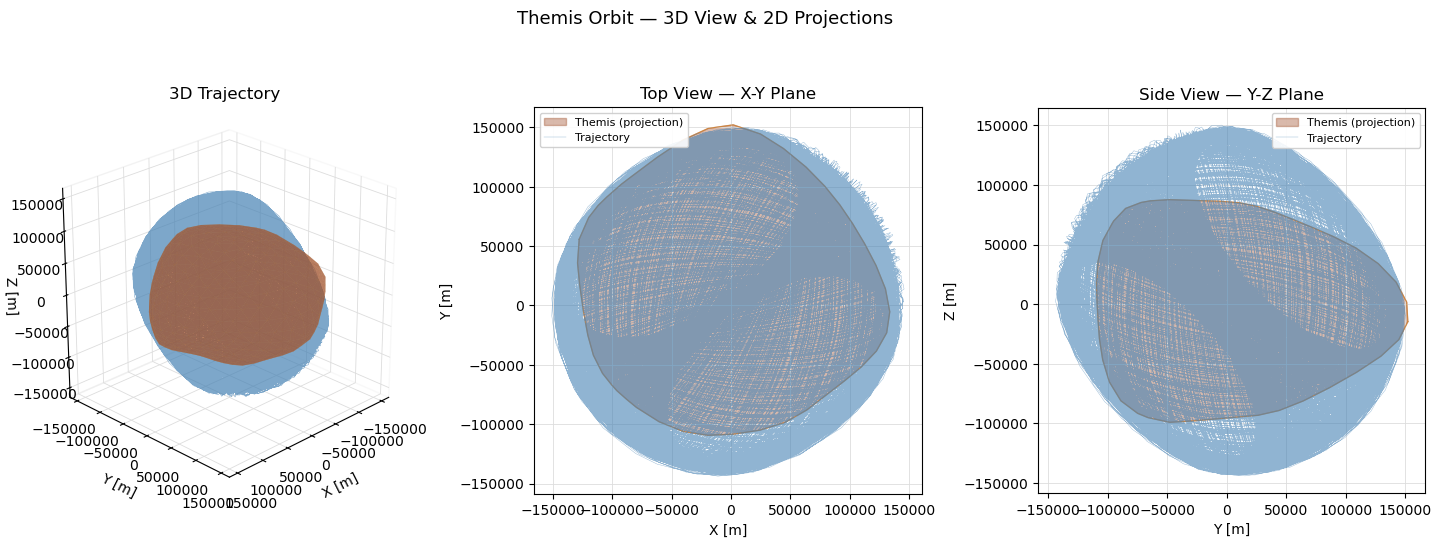

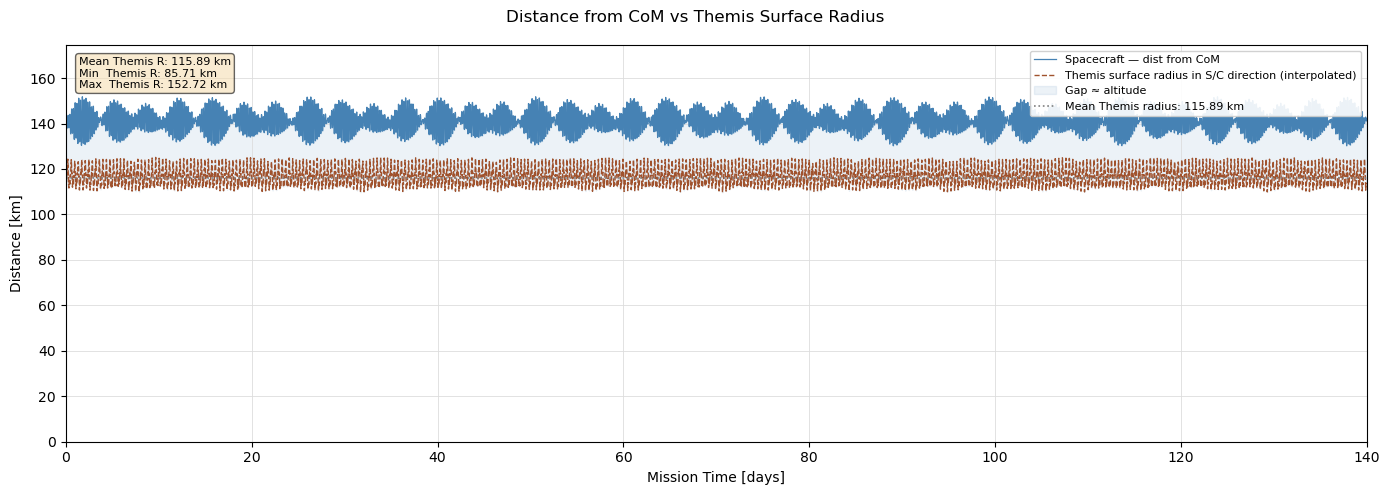

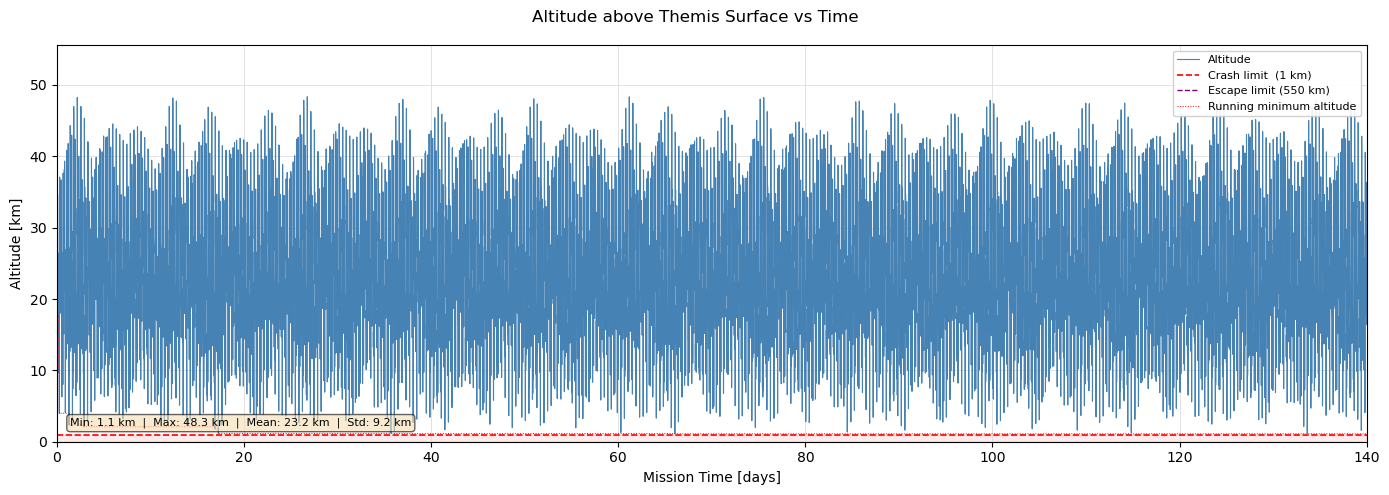

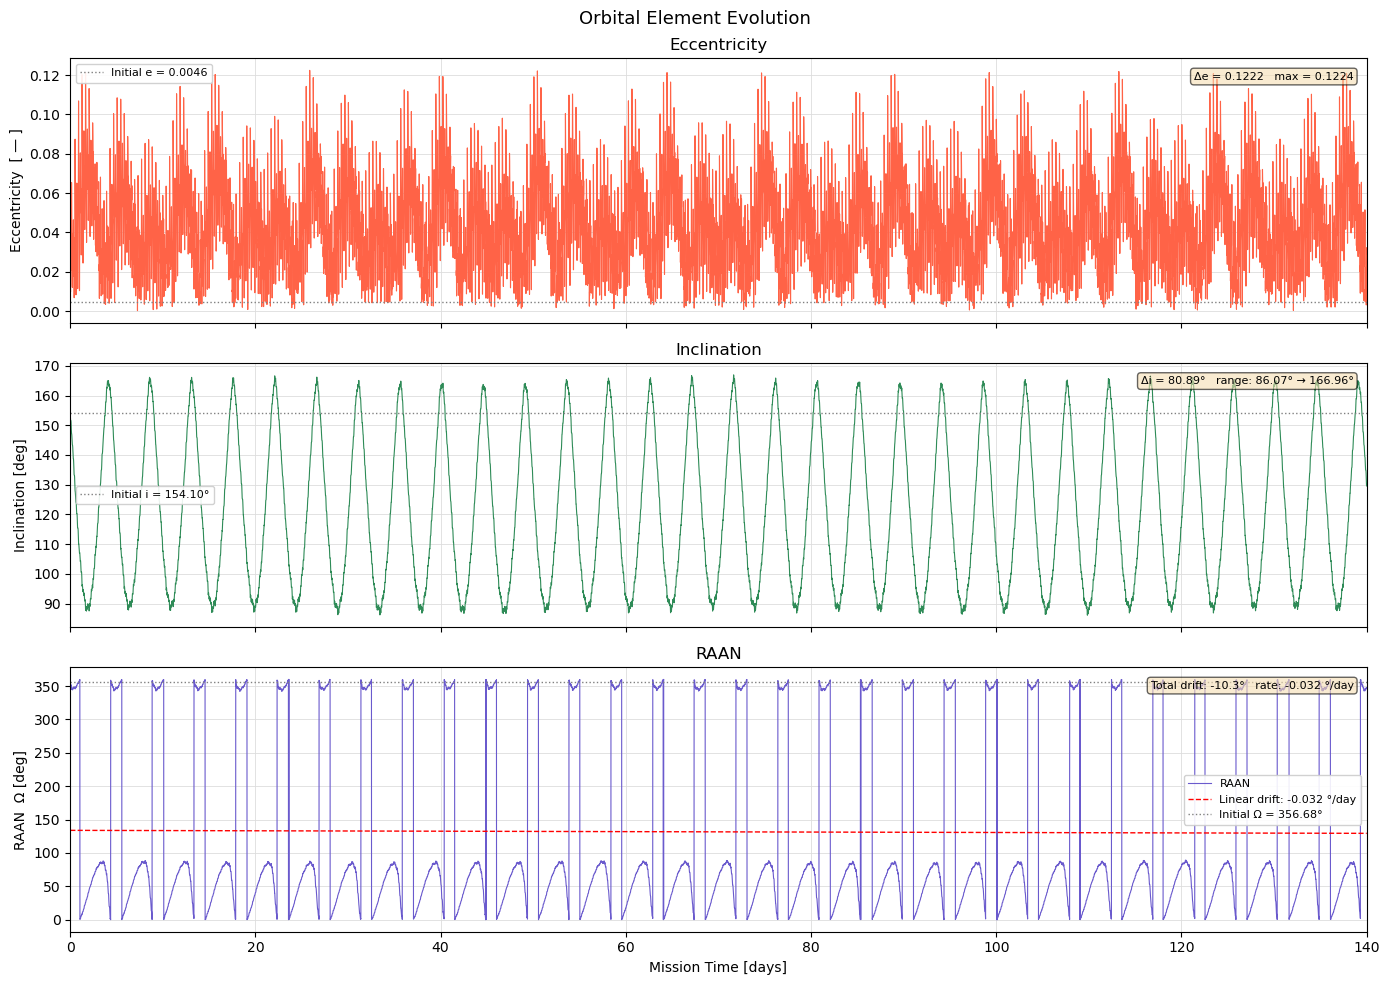


═══════════════════════════════════════════════════════
  MISSION SUMMARY
═══════════════════════════════════════════════════════
  Duration            : 140.00 days
  Altitude  — min     : 1.12 km
  Altitude  — max     : 48.35 km
  Altitude  — mean    : 23.20 km
  CoM dist  — min     : 130.23 km
  CoM dist  — max     : 151.78 km
  Themis R  — mean    : 115.893 km
  Themis R  — min     : 85.714 km
  Themis R  — max     : 152.716 km
  Eccentricity change : 0.0046 → 0.0289
  Inclination change  : 154.10° → 129.55°
  RAAN drift          : -10.3° total  (-0.032 °/day)
═══════════════════════════════════════════════════════


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.gridspec import GridSpec
from scipy.spatial import ConvexHull
from scipy.interpolate import griddata

# ══════════════════════════════════════════════════════════════════════════════
# 0. PULL DATA
# ══════════════════════════════════════════════════════════════════════════════
sim             = orbitProblem.get_last_run_dynamics_simulator()
state_history   = sim.propagation_results.state_history
dep_var_history = sim.propagation_results.dependent_variable_history

states_arr  = np.vstack(list(state_history.values()))
times_state = np.array(list(state_history.keys()))
x = states_arr[:, 0]
y = states_arr[:, 1]
z = states_arr[:, 2]

dep_arr  = np.vstack(list(dep_var_history.values()))
times_dv = np.array(list(dep_var_history.keys()))
days     = (times_dv - times_dv[0]) / 86400.0

# Column map (must match your get_dependent_variables_to_save order)
dist_com_km     = dep_arr[:, 0]  / 1e3    # spherical r = dist from CoM [km]
latitudes_rad   = dep_arr[:, 1]
longitudes_rad  = dep_arr[:, 2]
eccentricity    = dep_arr[:, 4]
inclination_deg = np.rad2deg(dep_arr[:, 5])
raan_deg        = np.rad2deg(dep_arr[:, 7])
altitude_km     = dep_arr[:, 9]  / 1e3    # true altitude above surface [km]

# ══════════════════════════════════════════════════════════════════════════════
# 1. THEMIS SURFACE RADIUS — smooth interpolation + mean radius
# ══════════════════════════════════════════════════════════════════════════════
# Compute radius, lat, lon of every vertex
vx = themis_vertices[:, 0]
vy = themis_vertices[:, 1]
vz = themis_vertices[:, 2]
r_v   = np.sqrt(vx**2 + vy**2 + vz**2)
lat_v = np.arcsin(np.clip(vz / r_v, -1, 1))
lon_v = np.arctan2(vy, vx)

# Mean radius — useful reference value
mean_themis_radius_m  = r_v.mean()
mean_themis_radius_km = mean_themis_radius_m / 1e3
min_themis_radius_km  = r_v.min()  / 1e3
max_themis_radius_km  = r_v.max()  / 1e3

print(f"Themis radius — mean : {mean_themis_radius_km:.3f} km")
print(f"Themis radius — min  : {min_themis_radius_km:.3f} km")
print(f"Themis radius — max  : {max_themis_radius_km:.3f} km")

# Smooth interpolation using scipy griddata (much better than nearest vertex)
# Build a dense lat/lon grid from vertices, interpolate to s/c positions
print("Interpolating surface radius along trajectory...")
surface_radius_km = griddata(
    points = np.column_stack([lat_v, lon_v]),   # known points (vertex positions)
    values = r_v / 1e3,                          # known radii [km]
    xi     = np.column_stack([latitudes_rad, longitudes_rad]),  # query points
    method = 'linear',                           # linear across triangles → smooth
    fill_value = mean_themis_radius_km           # fallback for extrapolation gaps
)

# Apply a light moving average to remove any remaining noise
window = 15
kernel = np.ones(window) / window
surface_radius_km_smooth = np.convolve(surface_radius_km, kernel, mode='same')
# Fix edge effects from convolution
surface_radius_km_smooth[:window//2]  = surface_radius_km_smooth[window//2]
surface_radius_km_smooth[-window//2:] = surface_radius_km_smooth[-window//2]
print("Done.")

# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL STYLE — simple, white background
# ══════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    'black',
    'axes.labelcolor':   'black',
    'axes.grid':         True,
    'grid.color':        '#dddddd',
    'grid.linewidth':    0.6,
    'xtick.color':       'black',
    'ytick.color':       'black',
    'text.color':        'black',
    'legend.framealpha': 0.9,
    'font.size':         10,
})

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — 3D orbit + X-Y and Y-Z projections
# ══════════════════════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(18, 6))
fig1.suptitle('Themis Orbit — 3D View & 2D Projections', fontsize=13)
gs1  = GridSpec(1, 3, figure=fig1, wspace=0.3)

# ── 3D ───────────────────────────────────────────────────────────────────────
ax3d = fig1.add_subplot(gs1[0, 0], projection='3d')
ax3d.set_facecolor('white')
ax3d.xaxis.pane.fill = False
ax3d.yaxis.pane.fill = False
ax3d.zaxis.pane.fill = False

# Themis mesh
poly_verts = themis_vertices[themis_faces]
mesh = Poly3DCollection(poly_verts, alpha=0.5,
                         facecolor='sienna', edgecolor='peru', linewidth=0.05)
ax3d.add_collection3d(mesh)

# Trajectory
ax3d.plot(x, y, z, color='steelblue', linewidth=0.4, alpha=0.7)

LIMS = max(np.abs(x).max(), np.abs(y).max(), np.abs(z).max()) * 1.1
ax3d.set_xlim(-LIMS, LIMS);  ax3d.set_xlabel('X [m]')
ax3d.set_ylim(-LIMS, LIMS);  ax3d.set_ylabel('Y [m]')
ax3d.set_zlim(-LIMS, LIMS);  ax3d.set_zlabel('Z [m]')
ax3d.set_box_aspect([1, 1, 1])
ax3d.set_title('3D Trajectory')
ax3d.view_init(elev=25, azim=45)

# ── X-Y projection ────────────────────────────────────────────────────────────
ax_xy = fig1.add_subplot(gs1[0, 1])
# Themis outline (convex hull of XY projection)
pts_xy  = np.column_stack([vx, vy])
hull_xy = ConvexHull(pts_xy)
hull_xy_pts = pts_xy[hull_xy.vertices]
hull_xy_pts = np.vstack([hull_xy_pts, hull_xy_pts[0]])
ax_xy.fill(hull_xy_pts[:, 0], hull_xy_pts[:, 1],
           color='sienna', alpha=0.4, label='Themis (projection)')
ax_xy.plot(hull_xy_pts[:, 0], hull_xy_pts[:, 1], color='peru', linewidth=0.8)
ax_xy.plot(x, y, color='steelblue', linewidth=0.3, alpha=0.6, label='Trajectory')
ax_xy.set_aspect('equal')
ax_xy.set_xlabel('X [m]');  ax_xy.set_ylabel('Y [m]')
ax_xy.set_title('Top View — X-Y Plane')
ax_xy.legend(fontsize=8)

# ── Y-Z projection ────────────────────────────────────────────────────────────
ax_yz = fig1.add_subplot(gs1[0, 2])
pts_yz  = np.column_stack([vy, vz])
hull_yz = ConvexHull(pts_yz)
hull_yz_pts = pts_yz[hull_yz.vertices]
hull_yz_pts = np.vstack([hull_yz_pts, hull_yz_pts[0]])
ax_yz.fill(hull_yz_pts[:, 0], hull_yz_pts[:, 1],
           color='sienna', alpha=0.4, label='Themis (projection)')
ax_yz.plot(hull_yz_pts[:, 0], hull_yz_pts[:, 1], color='peru', linewidth=0.8)
ax_yz.plot(y, z, color='steelblue', linewidth=0.3, alpha=0.6, label='Trajectory')
ax_yz.set_aspect('equal')
ax_yz.set_xlabel('Y [m]');  ax_yz.set_ylabel('Z [m]')
ax_yz.set_title('Side View — Y-Z Plane')
ax_yz.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_3d_projections.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — CoM distance vs Themis surface radius vs time
# ══════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(14, 5))
fig2.suptitle('Distance from CoM vs Themis Surface Radius', fontsize=12)

ax.plot(days, dist_com_km,          color='steelblue',  linewidth=0.9,
        label='Spacecraft — dist from CoM')
ax.plot(days, surface_radius_km_smooth, color='sienna', linewidth=1.0,
        linestyle='--', label='Themis surface radius in S/C direction (interpolated)')
ax.fill_between(days, surface_radius_km_smooth, dist_com_km,
                color='steelblue', alpha=0.10, label='Gap ≈ altitude')

ax.axhline(mean_themis_radius_km, color='gray', ls=':', lw=1.2,
           label=f'Mean Themis radius: {mean_themis_radius_km:.2f} km')

ax.set_xlabel('Mission Time [days]')
ax.set_ylabel('Distance [km]')
ax.set_xlim(0, days[-1])
ax.set_ylim(0, dist_com_km.max() * 1.15)
ax.legend(fontsize=8, loc='upper right')

# Stats box
txt = (f"Mean Themis R: {mean_themis_radius_km:.2f} km\n"
       f"Min  Themis R: {min_themis_radius_km:.2f} km\n"
       f"Max  Themis R: {max_themis_radius_km:.2f} km")
ax.text(0.01, 0.97, txt, transform=ax.transAxes, fontsize=8,
        va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.savefig('fig2_dist_vs_surface.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Altitude vs time
# ══════════════════════════════════════════════════════════════════════════════
fig3, ax = plt.subplots(figsize=(14, 5))
fig3.suptitle('Altitude above Themis Surface vs Time', fontsize=12)

ax.plot(days, altitude_km, color='steelblue', linewidth=0.8, label='Altitude')

ax.axhline(minimum_altitude / 1e3, color='red',    ls='--', lw=1.2,
           label=f'Crash limit  ({minimum_altitude/1e3:.0f} km)')
ax.axhline(maximum_altitude / 1e3, color='purple', ls='--', lw=1.0,
           label=f'Escape limit ({maximum_altitude/1e3:.0f} km)')

ax.fill_between(days, 0, minimum_altitude/1e3,
                color='red', alpha=0.08)
running_min = np.minimum.accumulate(altitude_km)
ax.plot(days, running_min, color='red', linewidth=0.7,
        linestyle=':', label='Running minimum altitude')

ax.set_xlabel('Mission Time [days]')
ax.set_ylabel('Altitude [km]')
ax.set_xlim(0, days[-1])
ax.set_ylim(0, altitude_km.max() * 1.15)
ax.legend(fontsize=8, loc='upper right')

txt = (f"Min: {altitude_km.min():.1f} km  |  "
       f"Max: {altitude_km.max():.1f} km  |  "
       f"Mean: {altitude_km.mean():.1f} km  |  "
       f"Std: {altitude_km.std():.1f} km")
ax.text(0.01, 0.04, txt, transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.savefig('fig3_altitude_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — e, i, RAAN vs time
# ══════════════════════════════════════════════════════════════════════════════
fig4, axes4 = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig4.suptitle('Orbital Element Evolution', fontsize=13)

# Eccentricity
axes4[0].plot(days, eccentricity, color='tomato', linewidth=0.8)
axes4[0].axhline(eccentricity[0], color='gray', ls=':', lw=1.0,
                  label=f'Initial e = {eccentricity[0]:.4f}')
axes4[0].set_ylabel('Eccentricity  [ — ]')
axes4[0].set_title('Eccentricity')
axes4[0].legend(fontsize=8)
axes4[0].text(0.99, 0.95,
              f'Δe = {eccentricity.max()-eccentricity.min():.4f}   '
              f'max = {eccentricity.max():.4f}',
              transform=axes4[0].transAxes, ha='right', va='top', fontsize=8,
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Inclination
axes4[1].plot(days, inclination_deg, color='seagreen', linewidth=0.8)
axes4[1].axhline(inclination_deg[0], color='gray', ls=':', lw=1.0,
                  label=f'Initial i = {inclination_deg[0]:.2f}°')
axes4[1].set_ylabel('Inclination [deg]')
axes4[1].set_title('Inclination')
axes4[1].legend(fontsize=8)
axes4[1].text(0.99, 0.95,
              f'Δi = {inclination_deg.max()-inclination_deg.min():.2f}°   '
              f'range: {inclination_deg.min():.2f}° → {inclination_deg.max():.2f}°',
              transform=axes4[1].transAxes, ha='right', va='top', fontsize=8,
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# RAAN
coeffs   = np.polyfit(days, raan_deg, 1)
raan_fit = np.polyval(coeffs, days)
axes4[2].plot(days, raan_deg,  color='slateblue', linewidth=0.8, label='RAAN')
axes4[2].plot(days, raan_fit,  color='red',       linewidth=1.0, ls='--',
              label=f'Linear drift: {coeffs[0]:.3f} °/day')
axes4[2].axhline(raan_deg[0], color='gray', ls=':', lw=1.0,
                  label=f'Initial Ω = {raan_deg[0]:.2f}°')
axes4[2].set_ylabel('RAAN  Ω [deg]')
axes4[2].set_xlabel('Mission Time [days]')
axes4[2].set_title('RAAN')
axes4[2].legend(fontsize=8)
axes4[2].text(0.99, 0.95,
              f'Total drift: {raan_deg[-1]-raan_deg[0]:.1f}°   '
              f'rate: {coeffs[0]:.3f} °/day',
              transform=axes4[2].transAxes, ha='right', va='top', fontsize=8,
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

for ax in axes4:
    ax.set_xlim(0, days[-1])

plt.tight_layout()
plt.savefig('fig4_orbital_elements.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*55)
print("  MISSION SUMMARY")
print("═"*55)
print(f"  Duration            : {days[-1]:.2f} days")
print(f"  Altitude  — min     : {altitude_km.min():.2f} km")
print(f"  Altitude  — max     : {altitude_km.max():.2f} km")
print(f"  Altitude  — mean    : {altitude_km.mean():.2f} km")
print(f"  CoM dist  — min     : {dist_com_km.min():.2f} km")
print(f"  CoM dist  — max     : {dist_com_km.max():.2f} km")
print(f"  Themis R  — mean    : {mean_themis_radius_km:.3f} km")
print(f"  Themis R  — min     : {min_themis_radius_km:.3f} km")
print(f"  Themis R  — max     : {max_themis_radius_km:.3f} km")
print(f"  Eccentricity change : {eccentricity[0]:.4f} → {eccentricity[-1]:.4f}")
print(f"  Inclination change  : {inclination_deg[0]:.2f}° → {inclination_deg[-1]:.2f}°")
print(f"  RAAN drift          : {raan_deg[-1]-raan_deg[0]:.1f}° total  "
      f"({coeffs[0]:.3f} °/day)")
print("═"*55)

Trajectory points used: 17887 / 17887
Computing coverage grid … (may take ~30 s for 7800 steps × 2592 cells)
Done.
Computing revisit intervals …
Done.


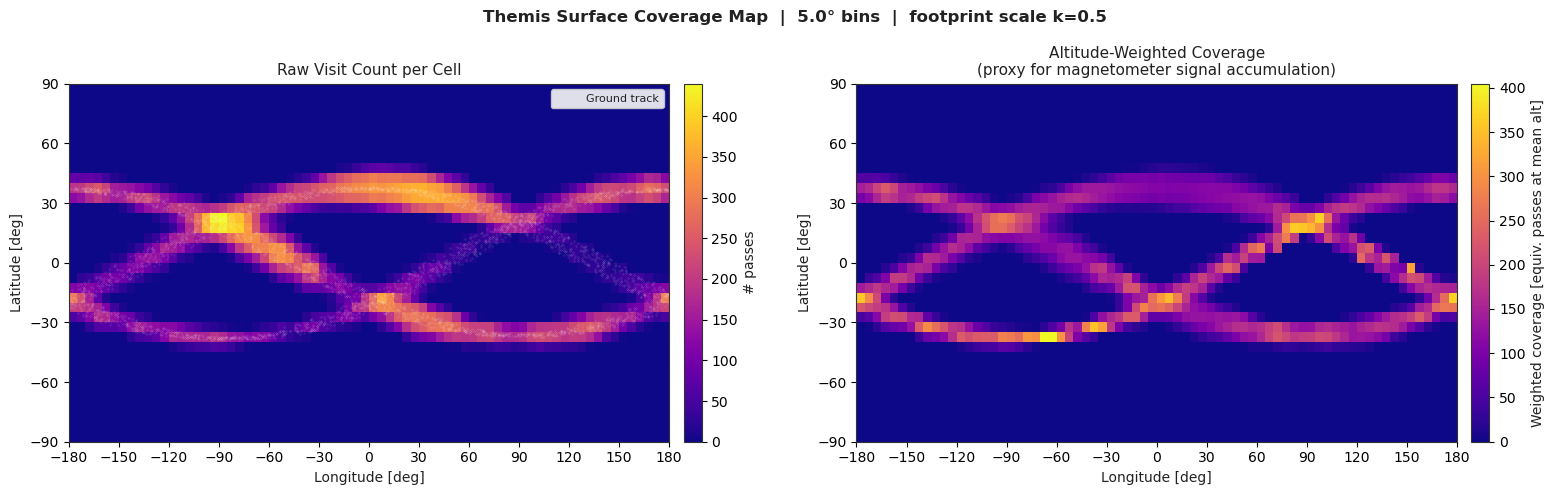

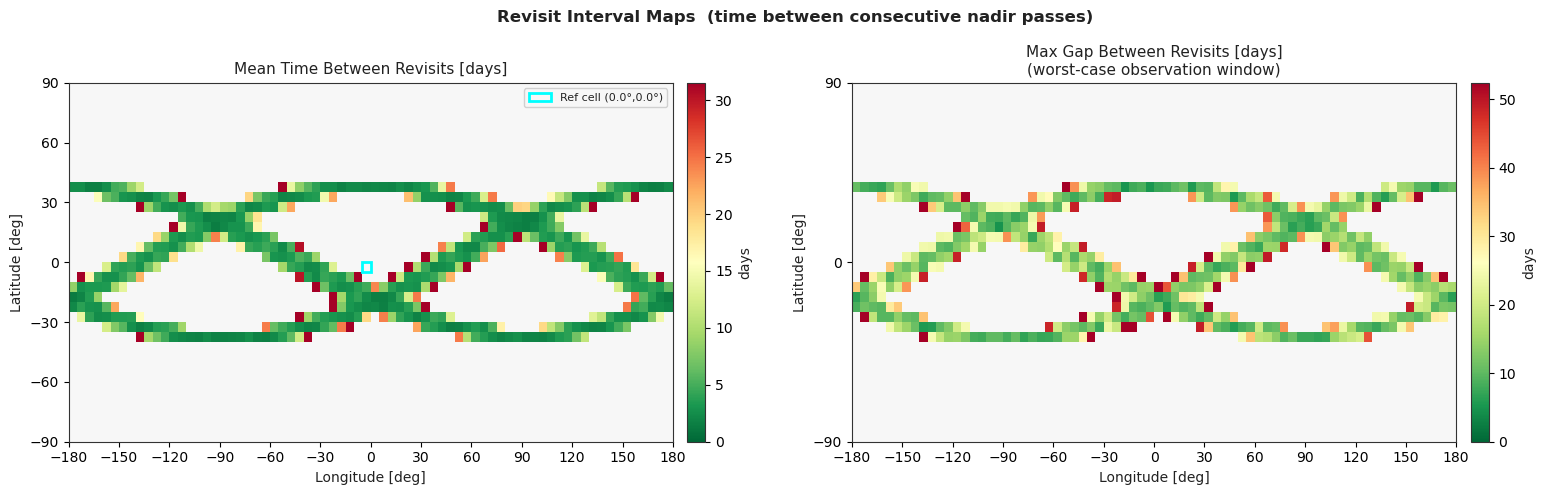

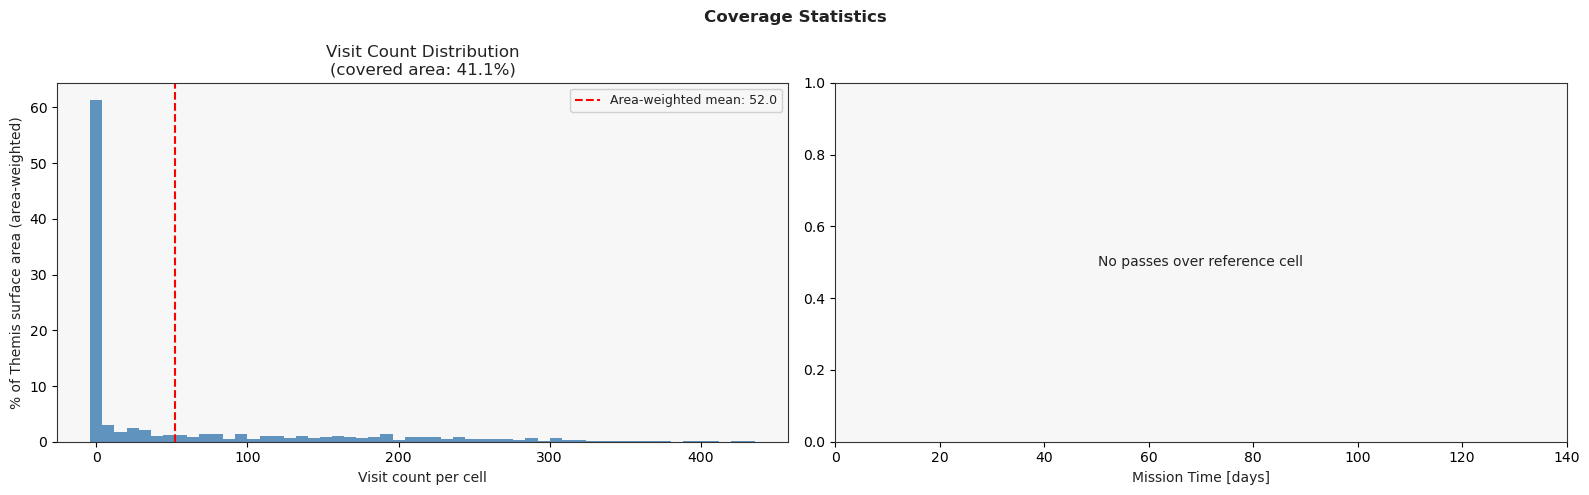


───────────────────────────────────────────────────────
  COVERAGE SUMMARY
───────────────────────────────────────────────────────
  Grid resolution      : 5.0° × 5.0°
  Cell area at equator : 10.1 km × 10.1 km
  Total cells          : 2592
  Cells visited (≥1)   : 766  (29.6%)
  Area-weighted coverage: 41.1%
  Mean visit count     : 127.7 passes
  Max visit count      : 440 passes
  Mean revisit gap     : 11.347 days  (272.3 h)
  Worst revisit gap    : 140.00 days
  Ref cell (0.0°,0.0°):
    Passes             : 0
───────────────────────────────────────────────────────



In [17]:
"""
Themis Magnetometer Coverage & Revisit Frequency Analysis
==========================================================
Paste this block into your Jupyter notebook after the existing Cell [16].
Requires: dep_arr, latitudes_rad, longitudes_rad, altitude_km, days,
          themis_vertices, minimum_altitude, maximum_altitude
          (all defined in Cell [16])

PRACTICAL NOTES FOR THE AVIONICS TEAM
--------------------------------------
1. Cell-size choice:
   - Themis mean radius ~115.9 km → circumference ~728 km
   - Mean orbital altitude ~76 km
   - Magnetometer resolution (rule of thumb: ~2 × altitude for dipole anomalies)
     ≈ 150 km — almost the diameter of Themis!
   - Conclusion: 2 km × 2 km bins are far finer than the instrument can resolve
     at these altitudes.  5° × 5° bins (~10 km) are recommended, and even those
     are optimistic; 10°–15° (~20–30 km) is physically more defensible.

2. Footprint model used here:
   - Simple altitude-scaled angular footprint: half-angle = arctan(k · h / R_Themis)
     where h = altitude and k = footprint_scale_factor (default 0.5).
   - This means at 76 km altitude the footprint radius on the surface is ~38 km
     or roughly ±19° (varies with altitude).

3. Better approaches for a real magnetometer study:
   a) Altitude-weighted revisit count:  weight each visit by 1/h² so low passes
      count more, high passes count less.
   b) Restrict analysis to a narrower altitude band (e.g. 40–90 km) and use
      that sub-set of the trajectory.
   c) Use a proper 3-D field inversion kernel (Backus-Gilbert or equivalent) to
      compute the true sensitivity distribution on the surface.
   d) For body rotation: the body-fixed lat/lon (dep_arr[:,1:3]) already accounts
      for Themis rotation — no extra correction needed.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy.ndimage import uniform_filter

# ─────────────────────────────────────────────────────────────────────────────
# 0. PARAMETERS  (tweak these)
# ─────────────────────────────────────────────────────────────────────────────
BIN_DEG          = 5.0           # grid cell size in degrees (lat & lon)
FOOTPRINT_SCALE  = 0.5           # footprint half-radius = scale × altitude [km]
                                  # on the surface (0.5 → 38 km at 76 km alt)
ALTITUDE_WEIGHT  = True          # if True: weight by 1/h² (signal strength proxy)
ALT_FILTER_LOW   = None          # set e.g. 40.0 to only count passes below 40 km
ALT_FILTER_HIGH  = None          # set e.g. 100.0 to ignore passes above 100 km
REVISIT_CELL_LAT = 0.0           # reference cell centre latitude  [deg]
REVISIT_CELL_LON = 0.0           # reference cell centre longitude [deg]
R_THEMIS_KM      = 115.893       # mean radius [km] — from your mesh

# ─────────────────────────────────────────────────────────────────────────────
# 1. BUILD LAT / LON GRID
# ─────────────────────────────────────────────────────────────────────────────
lat_edges = np.arange(-90,  90 + BIN_DEG, BIN_DEG)   # (n_lat+1,)
lon_edges = np.arange(-180, 180 + BIN_DEG, BIN_DEG)  # (n_lon+1,)
lat_centres = 0.5 * (lat_edges[:-1] + lat_edges[1:])  # (n_lat,)
lon_centres = 0.5 * (lon_edges[:-1] + lon_edges[1:])  # (n_lon,)
n_lat, n_lon = len(lat_centres), len(lon_centres)

LON_GRID, LAT_GRID = np.meshgrid(lon_centres, lat_centres)   # (n_lat, n_lon)

# Convert grid to radians for great-circle distance
lat_grid_r = np.deg2rad(LAT_GRID)   # (n_lat, n_lon)
lon_grid_r = np.deg2rad(LON_GRID)

# ─────────────────────────────────────────────────────────────────────────────
# 2. TRAJECTORY DATA — apply altitude filter if requested
# ─────────────────────────────────────────────────────────────────────────────
sc_lat_deg = np.rad2deg(latitudes_rad)    # sub-spacecraft latitude  [deg]
sc_lon_deg = np.rad2deg(longitudes_rad)   # sub-spacecraft longitude [deg]
sc_lat_r   = latitudes_rad
sc_lon_r   = longitudes_rad

mask = np.ones(len(altitude_km), dtype=bool)
if ALT_FILTER_LOW  is not None:  mask &= (altitude_km >= ALT_FILTER_LOW)
if ALT_FILTER_HIGH is not None:  mask &= (altitude_km <= ALT_FILTER_HIGH)

sc_lat_r_m   = sc_lat_r[mask]
sc_lon_r_m   = sc_lon_r[mask]
altitude_m   = altitude_km[mask]
days_m       = days[mask]

print(f"Trajectory points used: {mask.sum()} / {len(mask)}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. ACCUMULATE COVERAGE GRID
# ─────────────────────────────────────────────────────────────────────────────
# For each timestep: find all grid cells within the footprint radius and
# increment their counter (optionally weighted by 1/h²).

visit_count    = np.zeros((n_lat, n_lon), dtype=float)
weighted_count = np.zeros((n_lat, n_lon), dtype=float)

# Footprint half-angle on the surface [rad]
# = arcsin( footprint_km / R_Themis_km )  capped at 90°
footprint_km   = FOOTPRINT_SCALE * altitude_m          # (T,)
footprint_angle = np.arcsin(np.clip(footprint_km / R_THEMIS_KM, 0, 1))  # (T,)

print("Computing coverage grid … (may take ~30 s for 7800 steps × 2592 cells)")

for t in range(len(sc_lat_r_m)):
    slat = sc_lat_r_m[t]
    slon = sc_lon_r_m[t]
    fa   = footprint_angle[t]     # angular footprint radius [rad]
    w    = 1.0 / altitude_m[t]**2 if ALTITUDE_WEIGHT else 1.0

    # Great-circle distance from sub-spacecraft point to every grid cell
    # Haversine formula — vectorised over the grid
    dlat = lat_grid_r - slat
    dlon = lon_grid_r - slon
    a = np.sin(dlat / 2)**2 + np.cos(slat) * np.cos(lat_grid_r) * np.sin(dlon / 2)**2
    gc_dist = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))   # (n_lat, n_lon)

    in_footprint = gc_dist <= fa
    visit_count[in_footprint]    += 1.0
    weighted_count[in_footprint] += w

# Normalise weighted count so units are interpretable
# (relative to a visit at the mean altitude)
if ALTITUDE_WEIGHT:
    weighted_count_norm = weighted_count / (1.0 / np.mean(altitude_m)**2)
else:
    weighted_count_norm = weighted_count.copy()

print("Done.")

# ─────────────────────────────────────────────────────────────────────────────
# 4. REVISIT-INTERVAL MAP  (time between consecutive visits to each cell)
# ─────────────────────────────────────────────────────────────────────────────
# For every cell record the times at which the s/c sub-point was inside it,
# then compute mean gap between successive visits.

print("Computing revisit intervals …")

# Bin sub-spacecraft points directly
lat_idx = np.clip(np.searchsorted(lat_edges[1:], np.rad2deg(sc_lat_r_m)), 0, n_lat - 1)
lon_idx = np.clip(np.searchsorted(lon_edges[1:], np.rad2deg(sc_lon_r_m)), 0, n_lon - 1)

mean_gap_days  = np.full((n_lat, n_lon), np.nan)
max_gap_days   = np.full((n_lat, n_lon), np.nan)

# Build a dict: (i_lat, i_lon) → sorted list of visit times
from collections import defaultdict
visit_times = defaultdict(list)
for t in range(len(lat_idx)):
    visit_times[(lat_idx[t], lon_idx[t])].append(days_m[t])

for (i, j), times in visit_times.items():
    if len(times) > 1:
        gaps = np.diff(sorted(times))
        mean_gap_days[i, j] = gaps.mean()
        max_gap_days[i, j]  = gaps.max()
    else:
        mean_gap_days[i, j] = days_m[-1]   # visited only once → gap = mission duration
        max_gap_days[i, j]  = days_m[-1]

print("Done.")

# ─────────────────────────────────────────────────────────────────────────────
# 5. REVISIT-GAP TRACE for a single reference cell (useful for planning obs windows)
# ─────────────────────────────────────────────────────────────────────────────
ref_i = np.argmin(np.abs(lat_centres - REVISIT_CELL_LAT))
ref_j = np.argmin(np.abs(lon_centres - REVISIT_CELL_LON))
ref_times = np.array(sorted(visit_times.get((ref_i, ref_j), [])))
ref_gaps  = np.diff(ref_times) if len(ref_times) > 1 else np.array([])

# ─────────────────────────────────────────────────────────────────────────────
# 6. PLOTTING
# ─────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f7f7f7',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#222',
    'axes.grid': False, 'font.size': 10, 'text.color': '#222'
})

# ── Figure A: Visit count map (raw and weighted) ──────────────────────────────
fig_a, axes_a = plt.subplots(1, 2, figsize=(16, 5))
fig_a.suptitle(f'Themis Surface Coverage Map  |  {BIN_DEG}° bins  |  '
               f'footprint scale k={FOOTPRINT_SCALE}', fontsize=12, fontweight='bold')

cmap_hot = plt.cm.plasma

# Raw visit count
ax = axes_a[0]
im0 = ax.pcolormesh(lon_edges, lat_edges, visit_count, cmap=cmap_hot, shading='flat')
ax.set_title('Raw Visit Count per Cell', fontsize=11)
ax.set_xlabel('Longitude [deg]'); ax.set_ylabel('Latitude [deg]')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 30))
cbar0 = fig_a.colorbar(im0, ax=ax, pad=0.02)
cbar0.set_label('# passes')
# Ground track overlay (subsampled)
step = max(1, len(sc_lat_deg) // 3000)
ax.scatter(sc_lon_deg[::step], sc_lat_deg[::step],
           s=0.05, c='white', alpha=0.3, label='Ground track')
ax.legend(fontsize=8, loc='upper right')

# Altitude-weighted visit count
ax = axes_a[1]
im1 = ax.pcolormesh(lon_edges, lat_edges, weighted_count_norm, cmap=cmap_hot, shading='flat')
ax.set_title('Altitude-Weighted Coverage\n(proxy for magnetometer signal accumulation)', fontsize=11)
ax.set_xlabel('Longitude [deg]'); ax.set_ylabel('Latitude [deg]')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 30))
cbar1 = fig_a.colorbar(im1, ax=ax, pad=0.02)
cbar1.set_label('Weighted coverage [equiv. passes at mean alt]')

plt.tight_layout()
plt.savefig('figA_coverage_map.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure B: Revisit interval maps ──────────────────────────────────────────
fig_b, axes_b = plt.subplots(1, 2, figsize=(16, 5))
fig_b.suptitle('Revisit Interval Maps  (time between consecutive nadir passes)',
               fontsize=12, fontweight='bold')

# Mean revisit gap
ax = axes_b[0]
gap_plot = np.ma.masked_invalid(mean_gap_days)
im2 = ax.pcolormesh(lon_edges, lat_edges, gap_plot,
                    cmap='RdYlGn_r', shading='flat',
                    vmin=0, vmax=np.nanpercentile(mean_gap_days[~np.isnan(mean_gap_days)], 95))
ax.set_title('Mean Time Between Revisits [days]', fontsize=11)
ax.set_xlabel('Longitude [deg]'); ax.set_ylabel('Latitude [deg]')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 30))
# Mark reference cell
ax.add_patch(plt.Rectangle(
    (lon_edges[ref_j], lat_edges[ref_i]), BIN_DEG, BIN_DEG,
    fill=False, edgecolor='cyan', linewidth=2, label=f'Ref cell ({REVISIT_CELL_LAT}°,{REVISIT_CELL_LON}°)'
))
ax.legend(fontsize=8)
cbar2 = fig_b.colorbar(im2, ax=ax, pad=0.02)
cbar2.set_label('days')

# Max revisit gap (worst-case blackout)
ax = axes_b[1]
max_gap_plot = np.ma.masked_invalid(max_gap_days)
im3 = ax.pcolormesh(lon_edges, lat_edges, max_gap_plot,
                    cmap='RdYlGn_r', shading='flat',
                    vmin=0, vmax=np.nanpercentile(max_gap_days[~np.isnan(max_gap_days)], 95))
ax.set_title('Max Gap Between Revisits [days]\n(worst-case observation window)', fontsize=11)
ax.set_xlabel('Longitude [deg]'); ax.set_ylabel('Latitude [deg]')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 90))
cbar3 = fig_b.colorbar(im3, ax=ax, pad=0.02)
cbar3.set_label('days')

plt.tight_layout()
plt.savefig('figB_revisit_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure C: Coverage histogram + reference cell revisit trace ───────────────
fig_c, axes_c = plt.subplots(1, 2, figsize=(16, 5))
fig_c.suptitle('Coverage Statistics', fontsize=12, fontweight='bold')

# Histogram of visit counts (area-weighted by cos(lat))
ax = axes_c[0]
cos_weights = np.cos(np.deg2rad(LAT_GRID)).ravel()
counts_flat  = visit_count.ravel()
covered_frac = np.sum(cos_weights[counts_flat > 0]) / np.sum(cos_weights) * 100

# Build weighted histogram
bins_h = np.arange(0, visit_count.max() + 2, max(1, int(visit_count.max() / 50)))
hist_vals, bin_edges_h = np.histogram(counts_flat, bins=bins_h, weights=cos_weights)
hist_vals = hist_vals / hist_vals.sum() * 100  # percent of surface area

ax.bar(bin_edges_h[:-1], hist_vals, width=np.diff(bin_edges_h),
       color='steelblue', edgecolor='none', alpha=0.85)
ax.set_xlabel('Visit count per cell')
ax.set_ylabel('% of Themis surface area (area-weighted)')
ax.set_title(f'Visit Count Distribution\n(covered area: {covered_frac:.1f}%)')
ax.axvline(np.average(counts_flat, weights=cos_weights), color='red', ls='--',
           label=f'Area-weighted mean: {np.average(counts_flat, weights=cos_weights):.1f}')
ax.legend(fontsize=9)

# Revisit-time trace for reference cell
ax = axes_c[1]
if len(ref_times) > 0:
    ax.step(ref_times, np.arange(1, len(ref_times) + 1), where='post',
            color='steelblue', linewidth=1.5, label='Cumulative visits')
    ax.set_ylabel('Cumulative visit count', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')

    if len(ref_gaps) > 0:
        ax2 = ax.twinx()
        gap_x = ref_times[:-1] + ref_gaps / 2     # midpoint of each gap
        ax2.bar(gap_x, ref_gaps, width=ref_gaps * 0.6,
                color='tomato', alpha=0.6, label='Gap duration')
        ax2.set_ylabel('Gap between consecutive visits [days]', color='tomato')
        ax2.tick_params(axis='y', labelcolor='tomato')
        ax2.axhline(ref_gaps.mean(), color='darkred', ls='--', lw=1.2,
                    label=f'Mean gap = {ref_gaps.mean():.2f} days')
        ax2.legend(fontsize=8, loc='upper left')
        ax.set_title(f'Reference Cell: lat={lat_centres[ref_i]:.1f}°, '
                     f'lon={lon_centres[ref_j]:.1f}°\n'
                     f'{len(ref_times)} passes  |  mean gap {ref_gaps.mean():.2f} d  '
                     f'|  max gap {ref_gaps.max():.2f} d')
else:
    ax.text(0.5, 0.5, 'No passes over reference cell',
            ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel('Mission Time [days]')
ax.set_xlim(0, days_m[-1] if len(days_m) > 0 else days[-1])

plt.tight_layout()
plt.savefig('figC_coverage_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 7. SUMMARY STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
valid_gaps = mean_gap_days[~np.isnan(mean_gap_days)]
print("\n" + "─"*55)
print("  COVERAGE SUMMARY")
print("─"*55)
print(f"  Grid resolution      : {BIN_DEG}° × {BIN_DEG}°")
print(f"  Cell area at equator : {BIN_DEG * np.pi/180 * R_THEMIS_KM:.1f} km × "
      f"{BIN_DEG * np.pi/180 * R_THEMIS_KM:.1f} km")
print(f"  Total cells          : {n_lat * n_lon}")
print(f"  Cells visited (≥1)   : {(visit_count > 0).sum()}  "
      f"({(visit_count > 0).sum() / (n_lat*n_lon)*100:.1f}%)")
print(f"  Area-weighted coverage: {covered_frac:.1f}%")
print(f"  Mean visit count     : {visit_count[visit_count>0].mean():.1f} passes")
print(f"  Max visit count      : {visit_count.max():.0f} passes")
print(f"  Mean revisit gap     : {valid_gaps.mean():.3f} days  "
      f"({valid_gaps.mean()*24:.1f} h)")
print(f"  Worst revisit gap    : {max_gap_days[~np.isnan(max_gap_days)].max():.2f} days")
print(f"  Ref cell ({REVISIT_CELL_LAT}°,{REVISIT_CELL_LON}°):")
print(f"    Passes             : {len(ref_times)}")
if len(ref_gaps) > 0:
    print(f"    Mean gap           : {ref_gaps.mean():.3f} days  ({ref_gaps.mean()*24:.1f} h)")
    print(f"    Max gap            : {ref_gaps.max():.3f} days  ({ref_gaps.max()*24:.1f} h)")
print("─"*55)
print()


Total surface area (spherical): 168781.3 km²
Images taken (1 min cadence): 201,605

── Imager footprint at mean altitude (23.5 km) ────────────
  Width  (cross-track) : 1410.0 m  = 1.410 km
  Length (along-track) : 1879.9 m  = 1.880 km
  Image area           : 3.027 km²
  GSD                  : 1.17 m/px

Computing rectangular footprint coverage … (201,605 images × 36×72 cells)
(this may take 30–90 s)
Done.

── Imager coverage summary ─────────────────────────────────────────
  Cells imaged  : 783 / 2592  (43.4%)
  Area covered  : 73,272.5 km² / 168,781.3 km²
   50% area  :  NOT reached
   75% area  :  NOT reached
   90% area  :  NOT reached
   95% area  :  NOT reached
   99% area  :  NOT reached


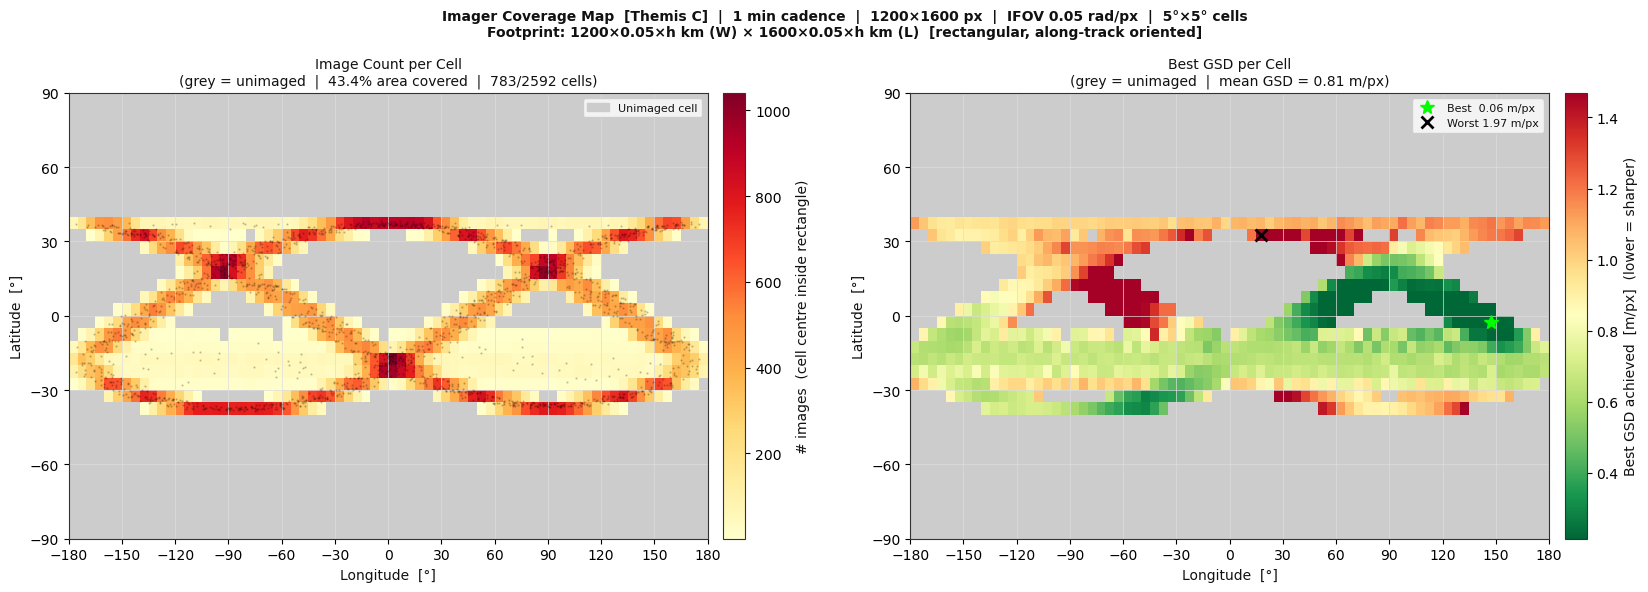

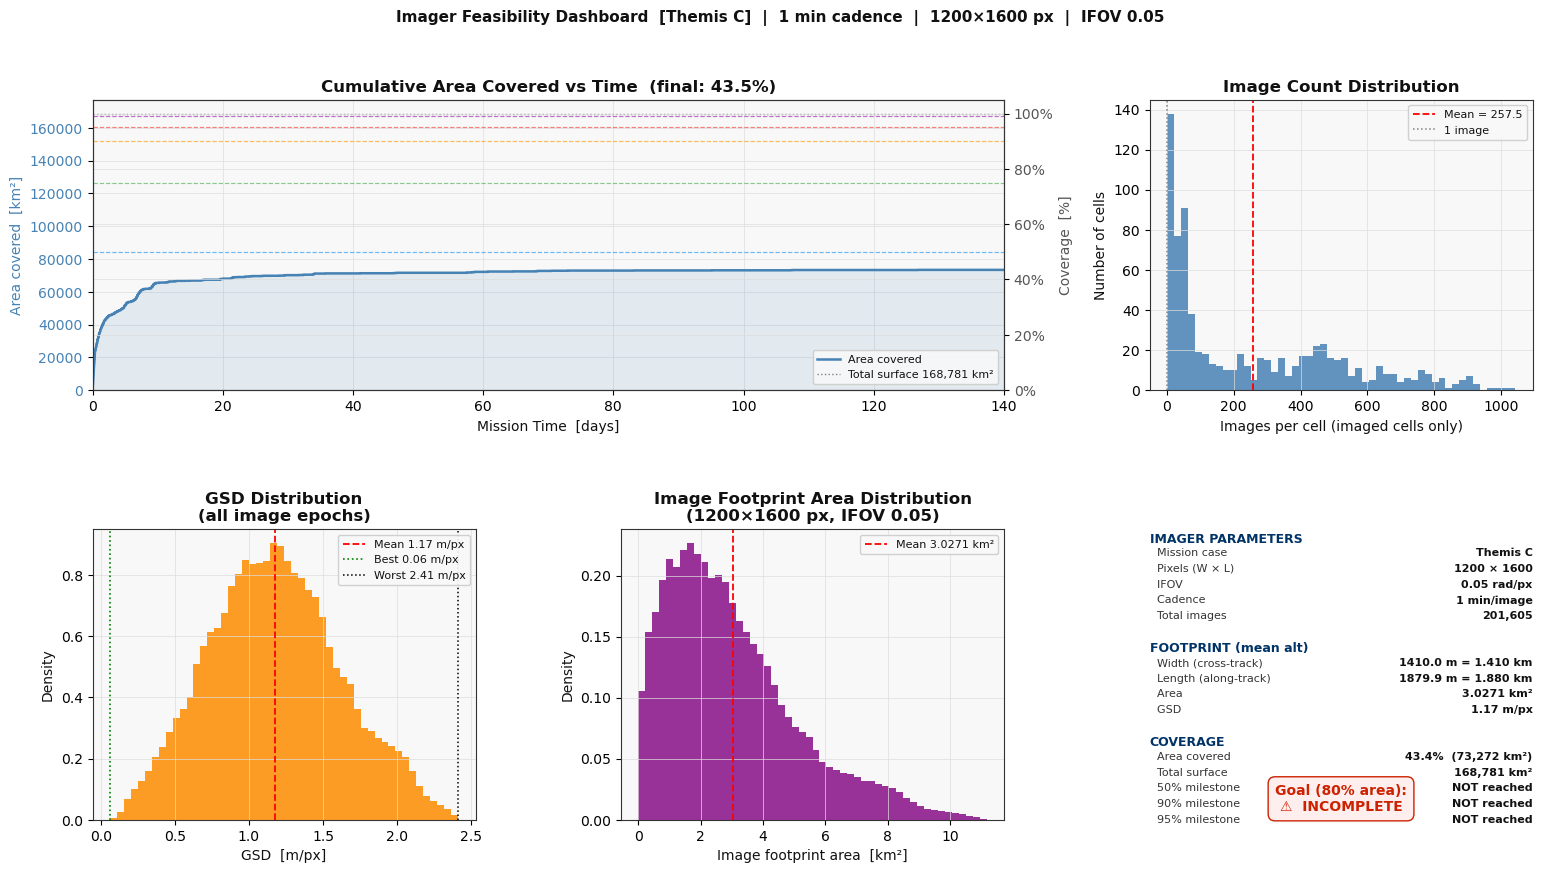

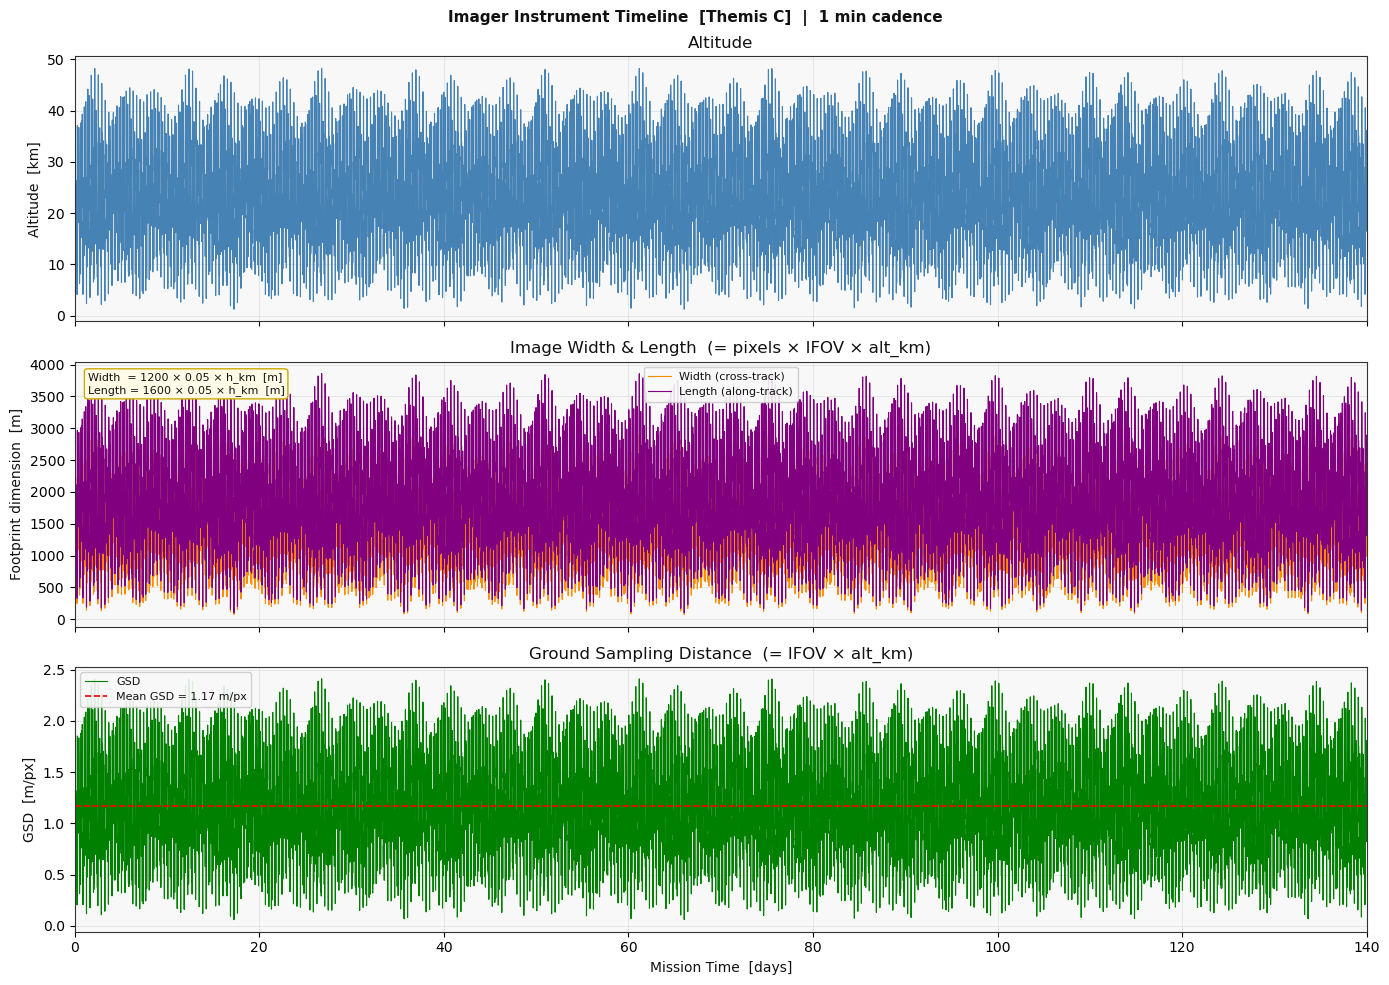


════════════════════════════════════════════════════════════
  IMAGER SUMMARY  [Themis C]
════════════════════════════════════════════════════════════
  Footprint model    : Rectangle (along-track oriented)
  Width formula      : 1200 × 0.05 × alt_km  [m]
  Length formula     : 1600 × 0.05 × alt_km  [m]
  Cell credited if   : cell CENTRE inside rectangle
  Total images       : 201,605
  GSD range          : 0.06 – 2.41 m/px
  Footprint W range  : 73.1 – 2894.5 m
  Footprint L range  : 97.4 – 3859.3 m
  Area covered       : 43.4%  (73,272.5 km²)
  Coverage verdict   : INCOMPLETE ⚠
════════════════════════════════════════════════════════════


In [18]:
"""
════════════════════════════════════════════════════════════════════════════════
  CELL 2 — MULTISPECTRAL IMAGER  ·  RECTANGULAR FOOTPRINT COVERAGE
  ──────────────────────────────────────────────────────────────────────────────
  REPLACE the existing imager cell with this one.

  Instrument model  (Themis B — change variables below for other cases)
  ──────────────────────────────────────────────────────────────────────
    Sampling rate  :  2 min / image
    Footprint shape:  Rectangle, oriented along ground track
    Width  [m]     =  1200 × 0.05 × altitude_km   (cross-track)
    Length [m]     =  1600 × 0.05 × altitude_km   (along-track)

  Coverage model
  ──────────────
    A 5°×5° cell is counted as imaged if its CENTRE falls inside the
    oriented rectangle at any image epoch.  This replaces the previous
    nadir-only or circular footprint approach.

  Requires (already in scope from earlier cells)
  ───────────────────────────────────────────────
    days, altitude_km, latitudes_rad, longitudes_rad
    states_arr  (cols 3-5 = vx,vy,vz in ECLIPJ2000)
    times_dv, times_state
    lat_edges, lon_edges, lat_centres, lon_centres, n_lat, n_lon, LAT_GRID
    R_THEMIS_KM, BIN_DEG
════════════════════════════════════════════════════════════════════════════════
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import defaultdict

# ════════════════════════════════════════════════════════════════════════════════
# 0.  MISSION / INSTRUMENT PARAMETERS  ← change here for different cases
# ════════════════════════════════════════════════════════════════════════════════
MISSION_CASE          = 'Themis C'          # label only
IMG_CADENCE_MIN       = 1.0                 # minutes between images
IMG_PIX_CROSS         = 1200               # detector pixels cross-track
IMG_PIX_ALONG         = 1600               # detector pixels along-track
IMG_IFOV              = 0.05               # IFOV [rad/pixel]  (both axes)
# Footprint formulas (from science team spec):
#   width_m  = IMG_PIX_CROSS × IMG_IFOV × alt_km   (cross-track)
#   length_m = IMG_PIX_ALONG × IMG_IFOV × alt_km   (along-track)
COVERAGE_GOAL_PCT     = 80.0               # feasibility threshold [%]
BIN_DEG_IMG           = 5.0               # must match magnetometer cell
R_THEMIS_KM_IMG       = 115.893           # mean radius [km]

# ════════════════════════════════════════════════════════════════════════════════
# 1.  GRID (re-use if already defined, else recompute)
# ════════════════════════════════════════════════════════════════════════════════
try:
    _ = lat_edges          # already defined
except NameError:
    lat_edges   = np.arange(-90,   90  + BIN_DEG_IMG, BIN_DEG_IMG)
    lon_edges   = np.arange(-180,  180 + BIN_DEG_IMG, BIN_DEG_IMG)
    lat_centres = 0.5 * (lat_edges[:-1] + lat_edges[1:])
    lon_centres = 0.5 * (lon_edges[:-1] + lon_edges[1:])
    n_lat       = len(lat_centres)
    n_lon       = len(lon_centres)
    LAT_GRID, _ = np.meshgrid(lat_centres, lon_centres, indexing='ij')

# Exact spherical cell areas [km²]
_dlon_r       = np.deg2rad(BIN_DEG_IMG)
cell_area_km2 = np.zeros((n_lat, n_lon))
for _ii, (_ls, _ln) in enumerate(zip(lat_edges[:-1], lat_edges[1:])):
    cell_area_km2[_ii, :] = (R_THEMIS_KM_IMG**2 * _dlon_r
                              * (np.sin(np.deg2rad(_ln))
                                 - np.sin(np.deg2rad(_ls))))
total_surface_area_km2 = cell_area_km2.sum()
print(f"Total surface area (spherical): {total_surface_area_km2:.1f} km²")

# Pre-compute cell-centre arrays in radians
_lat_c_r = np.deg2rad(lat_centres)   # (n_lat,)
_lon_c_r = np.deg2rad(lon_centres)   # (n_lon,)
_lat_e_r = np.deg2rad(lat_edges)   # (n_lat+1,)
_lon_e_r = np.deg2rad(lon_edges)   # (n_lon+1,)
# ════════════════════════════════════════════════════════════════════════════════
# 2.  IMAGE EPOCH TIMELINE  (uniform 2-min cadence)
# ════════════════════════════════════════════════════════════════════════════════
_IMG_CADENCE_S  = IMG_CADENCE_MIN * 60.0
_times_s_full   = (days - days[0]) * 86400.0
t_img_s         = np.arange(0, _times_s_full[-1], _IMG_CADENCE_S)
t_img_d         = t_img_s / 86400.0
N_img           = len(t_img_s)

# Interpolate altitude and body-fixed lat/lon to image epochs
alt_img         = np.interp(t_img_s, _times_s_full, altitude_km)      # km
lat_img_r       = np.interp(t_img_s, _times_s_full, latitudes_rad)    # rad
lon_img_r       = np.interp(t_img_s, _times_s_full, longitudes_rad)   # rad
lat_img_deg     = np.rad2deg(lat_img_r)
lon_img_deg     = np.rad2deg(lon_img_r)

print(f"Images taken ({IMG_CADENCE_MIN:.0f} min cadence): {N_img:,}")

# ════════════════════════════════════════════════════════════════════════════════
# 3.  FOOTPRINT DIMENSIONS AT EACH IMAGE EPOCH
# ════════════════════════════════════════════════════════════════════════════════
img_width_m    = IMG_PIX_CROSS * IMG_IFOV * alt_img * 1e3   # m   (note: alt in km → *1e3? NO)
# Correct formula: width_m = pixels × IFOV × alt_km
# IFOV in rad/px, alt in km → GSD = IFOV × alt_km [km/px] → width = pixels × GSD [km] × 1000 [m]
# BUT the spec says "Width in m = 1200 pixel × 0.05 × altitude (in km)"
# This gives: width_m = 1200 × 0.05 × alt_km = 60 × alt_km [m]  ← units as given
img_width_m    = IMG_PIX_CROSS * IMG_IFOV * alt_img           # [m]  as per spec
img_length_m   = IMG_PIX_ALONG * IMG_IFOV * alt_img           # [m]  as per spec
img_width_km   = img_width_m  / 1e3                           # [km]
img_length_km  = img_length_m / 1e3                           # [km]
img_area_km2   = img_width_km * img_length_km                 # [km²]

# GSD for reference (same as IFOV × alt)
gsd_m_px       = IMG_IFOV * alt_img * 1e3    # m/px  ... wait
# Spec: Width = 1200 × 0.05 × alt_km [m]
# So GSD (m/px) = 0.05 × alt_km × 1000/1000 ... let's just compute it directly
# GSD = alt_km × IFOV  [km/px]  → × 1000 → [m/px]  but IFOV=0.05 is in rad/px
# At 75 km: GSD = 75 × 0.05 = 3.75 km/px ??? That's huge.
# Wait - the spec says "Width in m = 1200 pixel × 0.05 × altitude (in km)"
# So width = 1200 × 0.05 × alt_km = 60 × alt_km [m]
# At alt=75km: width = 60×75 = 4500 m = 4.5 km
# GSD = 4500/1200 = 3.75 m/px    ← this makes sense
# So GSD [m/px] = 0.05 × alt_km × 1000 / 1000 = 0.05 × alt_km × 1 → 0.05 m/px per km?
# No: GSD = width/pixels = (0.05 × alt_km × 1200)/1200 = 0.05 × alt_km [m/px]
# At 75 km: GSD = 0.05 × 75 = 3.75 m/px ✓
gsd_m_px       = IMG_IFOV * alt_img   # [m/px]  (alt in km, IFOV in m/px/km effectively)

print(f"\n── Imager footprint at mean altitude ({alt_img.mean():.1f} km) ────────────")
print(f"  Width  (cross-track) : {img_width_km.mean()*1e3:.1f} m  = {img_width_km.mean():.3f} km")
print(f"  Length (along-track) : {img_length_km.mean()*1e3:.1f} m  = {img_length_km.mean():.3f} km")
print(f"  Image area           : {img_area_km2.mean():.3f} km²")
print(f"  GSD                  : {gsd_m_px.mean():.2f} m/px")

# ════════════════════════════════════════════════════════════════════════════════
# 4.  GROUND-TRACK HEADING AT EACH IMAGE EPOCH
#     heading = direction of motion measured from North, clockwise [rad]
#     Computed from finite differences of body-fixed nadir lat/lon.
# ════════════════════════════════════════════════════════════════════════════════
def _compute_headings(lat_r, lon_r):
    """
    Forward-difference heading for all but last point; backward for last.
    Returns array of headings [rad], same length as lat_r.
    """
    dlat = np.gradient(lat_r)
    dlon = np.gradient(lon_r)
    # East component accounts for convergence of meridians
    dE   = dlon * np.cos(lat_r)
    dN   = dlat
    return np.arctan2(dE, dN)   # angle from North, clockwise

heading_img = _compute_headings(lat_img_r, lon_img_r)   # [rad]

# ════════════════════════════════════════════════════════════════════════════════
# 5.  CELL-CENTRE RECTANGLE CHECK  (vectorised over the grid)
#     For each image k, check which (n_lat × n_lon) cell centres fall inside
#     the rotated rectangle centred at the nadir point.
#     Uses local flat-Earth approximation (valid: footprint ≪ R_Themis).
# ════════════════════════════════════════════════════════════════════════════════
img_count_map  = np.zeros((n_lat, n_lon), dtype=np.int32)
best_gsd_map   = np.full((n_lat, n_lon), np.nan)

# Pre-compute lat/lon offsets of all cell centres from every nadir point
# We do this vectorised: for each image, compute offsets and rotate.
# Shape broadcasting:
#   _lat_c_r  (n_lat,)   →  (n_lat, 1)
#   _lon_c_r  (n_lon,)   →  (1, n_lon)

print(f"\nComputing rectangular footprint coverage … ({N_img:,} images × {n_lat}×{n_lon} cells)")
print("(this may take 30–90 s)")

_half_len = img_length_km / 2.0   # (N_img,) along-track half-length [km]
_half_wid = img_width_km  / 2.0   # (N_img,) cross-track half-width  [km]

for k in range(N_img):
    _lat0 = lat_img_r[k]
    _lon0 = lon_img_r[k]
    _h    = heading_img[k]
    _hl   = _half_len[k]
    _hw   = _half_wid[k]
    sh, ch = np.sin(_h), np.cos(_h)

    # ── (A) CENTRE CHECK (original) ──────────────────────────────────────────
    dN_c = R_THEMIS_KM_IMG * (_lat_c_r - _lat0)
    dE_c = R_THEMIS_KM_IMG * np.cos(_lat0) * (_lon_c_r - _lon0)
    along_c = dE_c[np.newaxis, :] * sh + dN_c[:, np.newaxis] * ch
    cross_c = dE_c[np.newaxis, :] * ch - dN_c[:, np.newaxis] * sh
    centre_inside = (np.abs(along_c) <= _hl) & (np.abs(cross_c) <= _hw)

    # ── (B) MAXIMUM OVERLAP CELL (new) ───────────────────────────────────────
    # Project all cell-edge points into the rotated frame
    dN_e = R_THEMIS_KM_IMG * (_lat_e_r - _lat0)                      # (n_lat+1,)
    dE_e = R_THEMIS_KM_IMG * np.cos(_lat0) * (_lon_e_r - _lon0)      # (n_lon+1,)
    along_e = dE_e[np.newaxis, :] * sh + dN_e[:, np.newaxis] * ch    # (n_lat+1, n_lon+1)
    cross_e = dE_e[np.newaxis, :] * ch - dN_e[:, np.newaxis] * sh

    # Bounding box of each cell's 4 corners in rotated frame
    along_min = np.minimum(np.minimum(along_e[:-1, :-1], along_e[1:, :-1]),
                           np.minimum(along_e[:-1,  1:], along_e[1:,  1:]))  # (n_lat, n_lon)
    along_max = np.maximum(np.maximum(along_e[:-1, :-1], along_e[1:, :-1]),
                           np.maximum(along_e[:-1,  1:], along_e[1:,  1:]))
    cross_min = np.minimum(np.minimum(cross_e[:-1, :-1], cross_e[1:, :-1]),
                           np.minimum(cross_e[:-1,  1:], cross_e[1:,  1:]))
    cross_max = np.maximum(np.maximum(cross_e[:-1, :-1], cross_e[1:, :-1]),
                           np.maximum(cross_e[:-1,  1:], cross_e[1:,  1:]))

    # Intersection length along each axis (0 if no overlap)
    inter_along = np.maximum(0.0, np.minimum(along_max, _hl) - np.maximum(along_min, -_hl))
    inter_cross = np.maximum(0.0, np.minimum(cross_max, _hw) - np.maximum(cross_min, -_hw))

    # Approximate intersection area for every cell
    intersection_area = inter_along * inter_cross   # (n_lat, n_lon)

    # Select only the ONE cell with the largest intersection area
    max_overlap_cell = np.zeros((n_lat, n_lon), dtype=bool)
    best_flat = np.argmax(intersection_area)        # scalar index
    if intersection_area.ravel()[best_flat] > 0.0:
        max_overlap_cell[np.unravel_index(best_flat, (n_lat, n_lon))] = True

    # ── UNION: centre inside  OR  maximum-overlap cell ────────────────────────
    inside = centre_inside | max_overlap_cell

    img_count_map[inside] += 1
    _g = gsd_m_px[k]
    best_gsd_map[inside] = np.where(
        np.isnan(best_gsd_map[inside]) | (_g < best_gsd_map[inside]),
        _g, best_gsd_map[inside])

print("Done.")

# ════════════════════════════════════════════════════════════════════════════════
# 6.  INTER-IMAGE GAP PER CELL  (nadir binning for gap timing)
# ════════════════════════════════════════════════════════════════════════════════
lat_img_idx = np.clip(np.searchsorted(lat_edges[1:], lat_img_deg), 0, n_lat - 1)
lon_img_idx = np.clip(np.searchsorted(lon_edges[1:], lon_img_deg), 0, n_lon - 1)

cell_img_times = defaultdict(list)
for k in range(N_img):
    cell_img_times[(lat_img_idx[k], lon_img_idx[k])].append(t_img_d[k])

mean_img_gap_d = np.full((n_lat, n_lon), np.nan)
max_img_gap_d  = np.full((n_lat, n_lon), np.nan)
for (i, j), _tlist in cell_img_times.items():
    _ts = sorted(_tlist)
    if len(_ts) > 1:
        _g  = np.diff(_ts)
        mean_img_gap_d[i, j] = _g.mean()
        max_img_gap_d[i, j]  = _g.max()
    else:
        mean_img_gap_d[i, j] = t_img_d[-1]
        max_img_gap_d[i, j]  = t_img_d[-1]

# ════════════════════════════════════════════════════════════════════════════════
# 7.  COVERAGE STATISTICS  (area-weighted)
# ════════════════════════════════════════════════════════════════════════════════
covered_img_pct  = (np.sum(cell_area_km2 * (img_count_map > 0))
                    / total_surface_area_km2 * 100.0)
covered_area_km2 = total_surface_area_km2 * covered_img_pct / 100.0
cells_imaged     = int((img_count_map > 0).sum())
cells_total      = n_lat * n_lon

# Cumulative area covered vs time
_unique_seen   = set()
_cum_area      = np.zeros(N_img)
_run_area      = 0.0
for k in range(N_img):
    _c = (lat_img_idx[k], lon_img_idx[k])
    if _c not in _unique_seen:
        _unique_seen.add(_c)
        _run_area += cell_area_km2[_c[0], _c[1]]
    _cum_area[k] = _run_area
_cum_pct = _cum_area / total_surface_area_km2 * 100.0

thresholds  = [50, 75, 90, 95, 99]
thresh_days = {}
for _th in thresholds:
    _idx = np.where(_cum_pct >= _th)[0]
    thresh_days[_th] = t_img_d[_idx[0]] if len(_idx) else np.nan

print(f"\n── Imager coverage summary ─────────────────────────────────────────")
print(f"  Cells imaged  : {cells_imaged} / {cells_total}  ({covered_img_pct:.1f}%)")
print(f"  Area covered  : {covered_area_km2:,.1f} km² / {total_surface_area_km2:,.1f} km²")
for _th in thresholds:
    _d = thresh_days[_th]
    _s = f"day {_d:.1f}" if not np.isnan(_d) else "NOT reached"
    print(f"  {_th:>3}% area  :  {_s}")

# ════════════════════════════════════════════════════════════════════════════════
# 8.  PLOTS
# ════════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f8',
    'axes.edgecolor': '#333',    'axes.labelcolor': '#111',
    'axes.grid': True,           'grid.color': '#dddddd',
    'grid.linewidth': 0.5,       'font.size': 10, 'text.color': '#111',
})

# ── Figure IMG-1  :  Image count map + best GSD map ──────────────────────────
fig_e, axes_e = plt.subplots(1, 2, figsize=(17, 6))
fig_e.suptitle(
    f'Imager Coverage Map  [{MISSION_CASE}]  |  {IMG_CADENCE_MIN:.0f} min cadence  |  '
    f'{IMG_PIX_CROSS}×{IMG_PIX_ALONG} px  |  IFOV {IMG_IFOV} rad/px  |  5°×5° cells\n'
    f'Footprint: {IMG_PIX_CROSS}×{IMG_IFOV}×h km (W) × {IMG_PIX_ALONG}×{IMG_IFOV}×h km (L)  '
    f'[rectangular, along-track oriented]',
    fontsize=10, fontweight='bold')

# E-0  Image count map
ax = axes_e[0]
_img_ma = np.ma.masked_equal(img_count_map, 0)
im_e0   = ax.pcolormesh(lon_edges, lat_edges, _img_ma,
                         cmap='YlOrRd', shading='flat', vmin=1)
ax.pcolormesh(lon_edges, lat_edges,
              np.ma.masked_where(img_count_map > 0, np.ones((n_lat, n_lon))),
              cmap=mcolors.ListedColormap(['#cccccc']), shading='flat',
              vmin=0.5, vmax=1.5)
_st = max(1, N_img // 2000)
ax.scatter(lon_img_deg[::_st], lat_img_deg[::_st],
           s=0.4, c='black', alpha=0.2, zorder=4)
cbar_e0 = fig_e.colorbar(im_e0, ax=ax, pad=0.02)
cbar_e0.set_label('# images  (cell centre inside rectangle)')
ax.set_title(f'Image Count per Cell\n'
             f'(grey = unimaged  |  {covered_img_pct:.1f}% area covered  |  '
             f'{cells_imaged}/{cells_total} cells)', fontsize=10)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30)); ax.set_yticks(np.arange(-90, 91, 30))
ax.set_xlabel('Longitude  [°]'); ax.set_ylabel('Latitude  [°]')
ax.legend(handles=[mpatches.Patch(color='#cccccc', label='Unimaged cell')],
          fontsize=8, loc='upper right')

# E-1  Best GSD map
ax = axes_e[1]
_gsd_m_map = best_gsd_map   # m/px
_gsd_ma    = np.ma.masked_invalid(_gsd_m_map)
im_e1      = ax.pcolormesh(lon_edges, lat_edges, _gsd_ma,
                            cmap='RdYlGn_r', shading='flat',
                            vmin=np.nanpercentile(_gsd_m_map, 5),
                            vmax=np.nanpercentile(_gsd_m_map, 95))
ax.pcolormesh(lon_edges, lat_edges,
              np.ma.masked_where(~np.isnan(best_gsd_map), np.ones((n_lat, n_lon))),
              cmap=mcolors.ListedColormap(['#cccccc']), shading='flat',
              vmin=0.5, vmax=1.5)
cbar_e1 = fig_e.colorbar(im_e1, ax=ax, pad=0.02)
cbar_e1.set_label('Best GSD achieved  [m/px]  (lower = sharper)')
_best_ij  = np.unravel_index(np.nanargmin(best_gsd_map), (n_lat, n_lon))
_worst_ij = np.unravel_index(np.nanargmax(best_gsd_map), (n_lat, n_lon))
ax.plot(lon_centres[_best_ij[1]],  lat_centres[_best_ij[0]],
        '*', ms=10, color='lime',  zorder=6,
        label=f'Best  {best_gsd_map[_best_ij]:.2f} m/px')
ax.plot(lon_centres[_worst_ij[1]], lat_centres[_worst_ij[0]],
        'x', ms=8, color='black', zorder=6, markeredgewidth=2,
        label=f'Worst {best_gsd_map[_worst_ij]:.2f} m/px')
ax.set_title(f'Best GSD per Cell\n'
             f'(grey = unimaged  |  mean GSD = {np.nanmean(_gsd_m_map):.2f} m/px)',
             fontsize=10)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30)); ax.set_yticks(np.arange(-90, 91, 30))
ax.set_xlabel('Longitude  [°]'); ax.set_ylabel('Latitude  [°]')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('figIMG1_coverage_map.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure IMG-2  :  Cumulative area + GSD histogram + scorecard ─────────────
fig_g = plt.figure(figsize=(16, 9))
fig_g.suptitle(
    f'Imager Feasibility Dashboard  [{MISSION_CASE}]  |  '
    f'{IMG_CADENCE_MIN:.0f} min cadence  |  '
    f'{IMG_PIX_CROSS}×{IMG_PIX_ALONG} px  |  IFOV {IMG_IFOV}',
    fontsize=11, fontweight='bold')

gs_g = GridSpec(2, 3, figure=fig_g, wspace=0.38, hspace=0.48,
                left=0.07, right=0.97, top=0.88, bottom=0.08)

# G-0  Cumulative area covered vs time (dual axis)
ax     = fig_g.add_subplot(gs_g[0, :2])
ax2_pct = ax.twinx()
ax.plot(t_img_d, _cum_area, color='steelblue', lw=1.8, label='Area covered', zorder=4)
ax.fill_between(t_img_d, _cum_area, alpha=0.12, color='steelblue', zorder=3)
ax.axhline(total_surface_area_km2, color='gray', ls=':', lw=1.0,
           label=f'Total surface {total_surface_area_km2:,.0f} km²')
ax.set_xlabel('Mission Time  [days]')
ax.set_ylabel('Area covered  [km²]', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')
ax.set_xlim(0, t_img_d[-1]); ax.set_ylim(0, total_surface_area_km2 * 1.05)
ax2_pct.set_ylabel('Coverage  [%]', color='#555')
ax2_pct.tick_params(axis='y', labelcolor='#555')
ax2_pct.set_ylim(0, 105)
ax2_pct.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

_th_cols = {50:'#2196F3',75:'#4CAF50',90:'#FF9800',95:'#F44336',99:'#9C27B0'}
for _th, _col in _th_cols.items():
    _a_th = total_surface_area_km2 * _th / 100.0
    ax.axhline(_a_th, color=_col, ls='--', lw=0.85, alpha=0.65)
    _d = thresh_days[_th]
    if not np.isnan(_d):
        ax.axvline(_d, color=_col, ls=':', lw=1.1, alpha=0.75)
        ax.annotate(f'{_th}%\nday {_d:.1f}',
                    xy=(_d, _a_th),
                    xytext=(_d + t_img_d[-1]*0.015, _a_th + total_surface_area_km2*0.02),
                    fontsize=7, color=_col,
                    arrowprops=dict(arrowstyle='->', color=_col, lw=0.7))
ax.set_title(f'Cumulative Area Covered vs Time  '
             f'(final: {_cum_pct[-1]:.1f}%)', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

# G-1  Image count histogram
ax = fig_g.add_subplot(gs_g[0, 2])
_cnz = img_count_map[img_count_map > 0].ravel()
if len(_cnz) > 0:
    ax.hist(_cnz, bins=min(50, int(_cnz.max()-0.5)+1),
            color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(_cnz.mean(), color='red', ls='--', lw=1.3,
               label=f'Mean = {_cnz.mean():.1f}')
ax.axvline(1, color='gray', ls=':', lw=1.1, label='1 image')
ax.set_xlabel('Images per cell (imaged cells only)')
ax.set_ylabel('Number of cells')
ax.set_title('Image Count Distribution', fontweight='bold')
ax.legend(fontsize=8)

# G-2  GSD distribution
ax = fig_g.add_subplot(gs_g[1, 0])
_gsd_all = gsd_m_px
ax.hist(_gsd_all, bins=50, color='darkorange', edgecolor='none', alpha=0.85, density=True)
ax.axvline(_gsd_all.mean(), color='red',   ls='--', lw=1.3, label=f'Mean {_gsd_all.mean():.2f} m/px')
ax.axvline(_gsd_all.min(),  color='green', ls=':',  lw=1.2, label=f'Best {_gsd_all.min():.2f} m/px')
ax.axvline(_gsd_all.max(),  color='black', ls=':',  lw=1.1, label=f'Worst {_gsd_all.max():.2f} m/px')
ax.set_xlabel('GSD  [m/px]'); ax.set_ylabel('Density')
ax.set_title('GSD Distribution\n(all image epochs)', fontweight='bold')
ax.legend(fontsize=8)

# G-3  Footprint area distribution
ax = fig_g.add_subplot(gs_g[1, 1])
ax.hist(img_area_km2, bins=50, color='purple', edgecolor='none', alpha=0.80, density=True)
ax.axvline(img_area_km2.mean(), color='red', ls='--', lw=1.3,
           label=f'Mean {img_area_km2.mean():.4f} km²')
ax.set_xlabel('Image footprint area  [km²]'); ax.set_ylabel('Density')
ax.set_title(f'Image Footprint Area Distribution\n'
             f'({IMG_PIX_CROSS}×{IMG_PIX_ALONG} px, IFOV {IMG_IFOV})', fontweight='bold')
ax.legend(fontsize=8)

# G-4  Scorecard
ax = fig_g.add_subplot(gs_g[1, 2])
ax.axis('off')
_scorecard = [
    ('IMAGER PARAMETERS',        ''),
    ('  Mission case',            MISSION_CASE),
    ('  Pixels (W × L)',          f'{IMG_PIX_CROSS} × {IMG_PIX_ALONG}'),
    ('  IFOV',                    f'{IMG_IFOV} rad/px'),
    ('  Cadence',                 f'{IMG_CADENCE_MIN:.0f} min/image'),
    ('  Total images',            f'{N_img:,}'),
    ('',                          ''),
    ('FOOTPRINT (mean alt)',       ''),
    ('  Width (cross-track)',      f'{img_width_m.mean():.1f} m = {img_width_km.mean():.3f} km'),
    ('  Length (along-track)',     f'{img_length_m.mean():.1f} m = {img_length_km.mean():.3f} km'),
    ('  Area',                    f'{img_area_km2.mean():.4f} km²'),
    ('  GSD',                     f'{gsd_m_px.mean():.2f} m/px'),
    ('',                          ''),
    ('COVERAGE',                  ''),
    ('  Area covered',            f'{covered_img_pct:.1f}%  ({covered_area_km2:,.0f} km²)'),
    ('  Total surface',           f'{total_surface_area_km2:,.0f} km²'),
    ('  50% milestone',           f'day {thresh_days[50]:.1f}' if not np.isnan(thresh_days[50]) else 'NOT reached'),
    ('  90% milestone',           f'day {thresh_days[90]:.1f}' if not np.isnan(thresh_days[90]) else 'NOT reached'),
    ('  95% milestone',           f'day {thresh_days[95]:.1f}' if not np.isnan(thresh_days[95]) else 'NOT reached'),
]
_y0 = 0.99
for _lbl, _val in _scorecard:
    if _val == '':
        ax.text(0.0, _y0, _lbl, fontsize=9, fontweight='bold', va='top',
                transform=ax.transAxes, color='#003366')
    else:
        ax.text(0.0, _y0, _lbl, fontsize=8, va='top', transform=ax.transAxes, color='#333')
        ax.text(1.0, _y0, _val, fontsize=8, va='top', ha='right',
                transform=ax.transAxes, color='#111', fontweight='bold')
    _y0 -= 0.054

_feasible    = covered_img_pct >= COVERAGE_GOAL_PCT
_vcol        = '#1a7a1a' if _feasible else '#cc2200'
_vtxt        = '✓  FEASIBLE' if _feasible else '⚠  INCOMPLETE'
ax.text(0.5, 0.02, f'Goal ({COVERAGE_GOAL_PCT:.0f}% area):\n{_vtxt}',
        ha='center', va='bottom', transform=ax.transAxes,
        fontsize=10, fontweight='bold', color=_vcol,
        bbox=dict(facecolor='#eeffee' if _feasible else '#ffeeee',
                  edgecolor=_vcol, boxstyle='round,pad=0.5'))

plt.savefig('figIMG2_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure IMG-3  :  Footprint dimensions vs altitude ────────────────────────
fig_h, axes_h = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig_h.suptitle(f'Imager Instrument Timeline  [{MISSION_CASE}]  |  '
               f'{IMG_CADENCE_MIN:.0f} min cadence', fontsize=11, fontweight='bold')

axes_h[0].plot(t_img_d, alt_img, color='steelblue', lw=0.8)
axes_h[0].set_ylabel('Altitude  [km]'); axes_h[0].set_title('Altitude')

axes_h[1].plot(t_img_d, img_width_m, color='darkorange', lw=0.8, label='Width (cross-track)')
axes_h[1].plot(t_img_d, img_length_m, color='purple',    lw=0.8, label='Length (along-track)')
axes_h[1].set_ylabel('Footprint dimension  [m]')
axes_h[1].set_title('Image Width & Length  (= pixels × IFOV × alt_km)')
axes_h[1].legend(fontsize=8)
axes_h[1].text(0.01, 0.96,
    f'Width  = {IMG_PIX_CROSS} × {IMG_IFOV} × h_km  [m]\n'
    f'Length = {IMG_PIX_ALONG} × {IMG_IFOV} × h_km  [m]',
    transform=axes_h[1].transAxes, fontsize=8, va='top',
    bbox=dict(facecolor='#fffbe6', edgecolor='#ccaa00', boxstyle='round,pad=0.3'))

axes_h[2].plot(t_img_d, gsd_m_px, color='green', lw=0.8, label='GSD')
axes_h[2].axhline(gsd_m_px.mean(), color='red', ls='--', lw=1.2,
                  label=f'Mean GSD = {gsd_m_px.mean():.2f} m/px')
axes_h[2].set_ylabel('GSD  [m/px]'); axes_h[2].set_xlabel('Mission Time  [days]')
axes_h[2].set_title('Ground Sampling Distance  (= IFOV × alt_km)')
axes_h[2].legend(fontsize=8)
axes_h[2].set_xlim(0, t_img_d[-1])

plt.tight_layout()
plt.savefig('figIMG3_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'═'*60}")
print(f"  IMAGER SUMMARY  [{MISSION_CASE}]")
print(f"{'═'*60}")
print(f"  Footprint model    : Rectangle (along-track oriented)")
print(f"  Width formula      : {IMG_PIX_CROSS} × {IMG_IFOV} × alt_km  [m]")
print(f"  Length formula     : {IMG_PIX_ALONG} × {IMG_IFOV} × alt_km  [m]")
print(f"  Cell credited if   : cell CENTRE inside rectangle")
print(f"  Total images       : {N_img:,}")
print(f"  GSD range          : {gsd_m_px.min():.2f} – {gsd_m_px.max():.2f} m/px")
print(f"  Footprint W range  : {img_width_m.min():.1f} – {img_width_m.max():.1f} m")
print(f"  Footprint L range  : {img_length_m.min():.1f} – {img_length_m.max():.1f} m")
print(f"  Area covered       : {covered_img_pct:.1f}%  ({covered_area_km2:,.1f} km²)")
_feasible = covered_img_pct >= COVERAGE_GOAL_PCT
print(f"  Coverage verdict   : {'FEASIBLE ✓' if _feasible else 'INCOMPLETE ⚠'}")
print(f"{'═'*60}")

In [19]:
"""
════════════════════════════════════════════════════════════════════════
  CELL 1 — TRAJECTORY CSV EXPORT
  ──────────────────────────────────────────────────────────────────────
  Paste as a NEW CELL anywhere after the main data-extraction cell
  (the one that defines states_arr, dep_arr, times_state, times_dv).

  Columns saved
  ─────────────
  t_s          mission elapsed time              [s]
  t_days       mission elapsed time              [days]
  x_m          inertial X  (ECLIPJ2000)          [m]
  y_m          inertial Y  (ECLIPJ2000)          [m]
  z_m          inertial Z  (ECLIPJ2000)          [m]
  vx_ms        inertial Vx (ECLIPJ2000)          [m/s]
  vy_ms        inertial Vy (ECLIPJ2000)          [m/s]
  vz_ms        inertial Vz (ECLIPJ2000)          [m/s]
  lon_deg      body-fixed longitude              [deg]
  lat_deg      body-fixed latitude               [deg]
  sma_m        semi-major axis                   [m]
  ecc          eccentricity                      [-]
  inc_deg      inclination                       [deg]
  aop_deg      argument of periapsis             [deg]
  raan_deg     right ascension of ascending node [deg]
  alt_km       true altitude above surface       [km]
════════════════════════════════════════════════════════════════════════
"""

import numpy as np
import pandas as pd
import os

# ── OUTPUT SETTINGS  ← change path here ─────────────────────────────
CSV_OUTPUT_PATH = r'D:\CALTECH_MS_SPACE_ENGINEERING\105c\themis_C_25km_trajectory.csv'

# ════════════════════════════════════════════════════════════════════════
# 1.  ALIGN STATE & DEPENDENT-VARIABLE ARRAYS TO A COMMON TIME BASE
#     state_history  →  times_state  (may differ in length from times_dv)
#     dep_var_history →  times_dv
#     Strategy: interpolate inertial state to the dep_var time stamps,
#     so every row has both state and orbital-element data at the same t.
# ════════════════════════════════════════════════════════════════════════
_t0 = times_dv[0]                           # reference epoch [s]
t_elapsed_s    = times_dv - _t0             # [s] from mission start
t_elapsed_days = t_elapsed_s / 86400.0      # [days]

# Inertial position — already available at dep_var times?
# Guard: if state and dep_var share the same timestamps (usual case),
# use directly; otherwise interpolate.
if len(times_state) == len(times_dv) and np.allclose(times_state, times_dv, rtol=1e-9):
    x_out  = states_arr[:, 0]
    y_out  = states_arr[:, 1]
    z_out  = states_arr[:, 2]
    vx_out = states_arr[:, 3]
    vy_out = states_arr[:, 4]
    vz_out = states_arr[:, 5]
else:
    # Interpolate state to dep_var timestamps
    x_out  = np.interp(times_dv, times_state, states_arr[:, 0])
    y_out  = np.interp(times_dv, times_state, states_arr[:, 1])
    z_out  = np.interp(times_dv, times_state, states_arr[:, 2])
    vx_out = np.interp(times_dv, times_state, states_arr[:, 3])
    vy_out = np.interp(times_dv, times_state, states_arr[:, 4])
    vz_out = np.interp(times_dv, times_state, states_arr[:, 5])

# ════════════════════════════════════════════════════════════════════════
# 2.  EXTRACT DEP-VAR COLUMNS
#     dep_arr column map (from get_dependent_variables_to_save):
#       0  → dist from CoM  (spherical r)  [m]
#       1  → latitude       (body-fixed)   [rad]
#       2  → longitude      (body-fixed)   [rad]
#       3  → semi-major axis               [m]
#       4  → eccentricity                  [-]
#       5  → inclination                   [rad]
#       6  → argument of periapsis         [rad]
#       7  → RAAN                          [rad]
#       8  → true anomaly                  [rad]
#       9  → true altitude above surface   [m]
#      10  → distance from CoM             [m]
# ════════════════════════════════════════════════════════════════════════
lon_deg_out  = np.rad2deg(dep_arr[:, 2])
lat_deg_out  = np.rad2deg(dep_arr[:, 1])
sma_m_out    = dep_arr[:, 3]
ecc_out      = dep_arr[:, 4]
inc_deg_out  = np.rad2deg(dep_arr[:, 5])
aop_deg_out  = np.rad2deg(dep_arr[:, 6])
raan_deg_out = np.rad2deg(dep_arr[:, 7])
alt_km_out   = dep_arr[:, 9] / 1e3

# ════════════════════════════════════════════════════════════════════════
# 3.  BUILD DATAFRAME & SAVE
# ════════════════════════════════════════════════════════════════════════
df = pd.DataFrame({
    't_s'       : t_elapsed_s,
    't_days'    : t_elapsed_days,
    'x_m'       : x_out,
    'y_m'       : y_out,
    'z_m'       : z_out,
    'vx_ms'     : vx_out,
    'vy_ms'     : vy_out,
    'vz_ms'     : vz_out,
    'lon_deg'   : lon_deg_out,
    'lat_deg'   : lat_deg_out,
    'sma_m'     : sma_m_out,
    'ecc'       : ecc_out,
    'inc_deg'   : inc_deg_out,
    'aop_deg'   : aop_deg_out,
    'raan_deg'  : raan_deg_out,
    'alt_km'    : alt_km_out,
})

# Make sure output directory exists
os.makedirs(os.path.dirname(CSV_OUTPUT_PATH), exist_ok=True)

df.to_csv(CSV_OUTPUT_PATH, index=False, float_format='%.10g')

print(f"CSV saved  →  {CSV_OUTPUT_PATH}")
print(f"Rows       :  {len(df):,}")
print(f"Columns    :  {list(df.columns)}")
print(f"\nFirst row preview:")
print(df.iloc[0].to_string())
print(f"\nSummary statistics (selected columns):")
print(df[['alt_km','ecc','inc_deg','sma_m']].describe().to_string())

CSV saved  →  D:\CALTECH_MS_SPACE_ENGINEERING\105c\themis_C_25km_trajectory.csv
Rows       :  17,887
Columns    :  ['t_s', 't_days', 'x_m', 'y_m', 'z_m', 'vx_ms', 'vy_ms', 'vz_ms', 'lon_deg', 'lat_deg', 'sma_m', 'ecc', 'inc_deg', 'aop_deg', 'raan_deg', 'alt_km']

First row preview:
t_s              0.000000
t_days           0.000000
x_m         133132.392370
y_m         -41699.403655
z_m          16470.369335
vx_ms          -16.372142
vy_ms          -44.153135
vz_ms           21.864025
lon_deg        107.884208
lat_deg        -34.689163
sma_m       139989.999972
ecc              0.004580
inc_deg        154.100000
aop_deg        235.699998
raan_deg       356.680000
alt_km          28.161380

Summary statistics (selected columns):
             alt_km           ecc       inc_deg          sma_m
count  17887.000000  17887.000000  17887.000000   17887.000000
mean      23.204595      0.045809    121.594852  144077.447345
std        9.166796      0.022881     25.587028    2519.583120
min      

Total surface area: 168781.3 km²
Spectrometer cubes (2 min cadence): 100,803
Orbital velocity range: 47.98 – 56.90 m/s  (mean 52.12 m/s)

── Spectrometer footprint at mean altitude (23.5 km) ──────
  Width  (cross-track) : 1504.0 m  = 1.504 km  (= alt_km × 64)
  Length (along-track) : 781.8 m  = 0.782 km  (= v_orb × 15 s)
  Footprint area       : 1.1669 km²

Computing spectrometer rectangular coverage … (100,803 cubes × 36×72 cells)
(this may take 30–90 s)
Done.

── Spectrometer coverage summary ──────────────────────────────────────
  Cells covered : 764 / 2592  (42.3%)
  Area covered  : 71,473.3 km² / 168,781.3 km²
   50% area  :  NOT reached
   75% area  :  NOT reached
   90% area  :  NOT reached
   95% area  :  NOT reached
   99% area  :  NOT reached


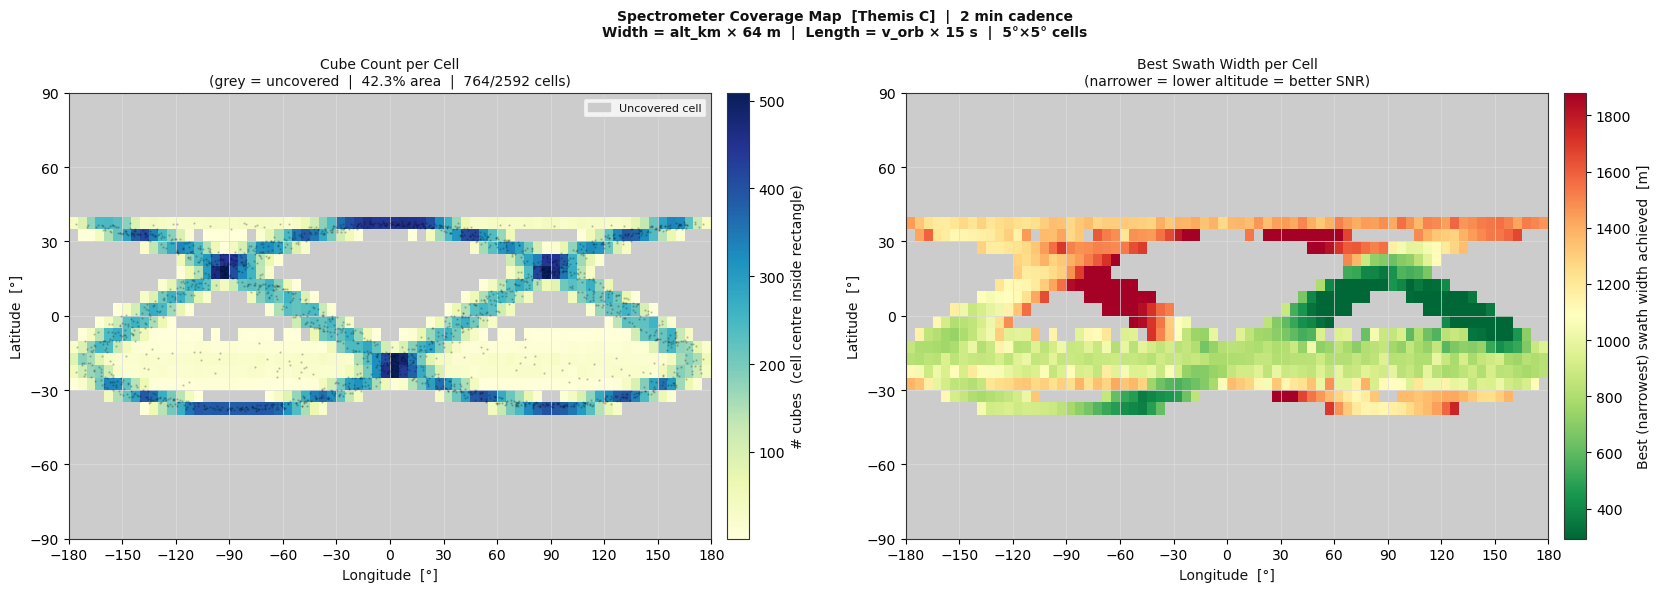

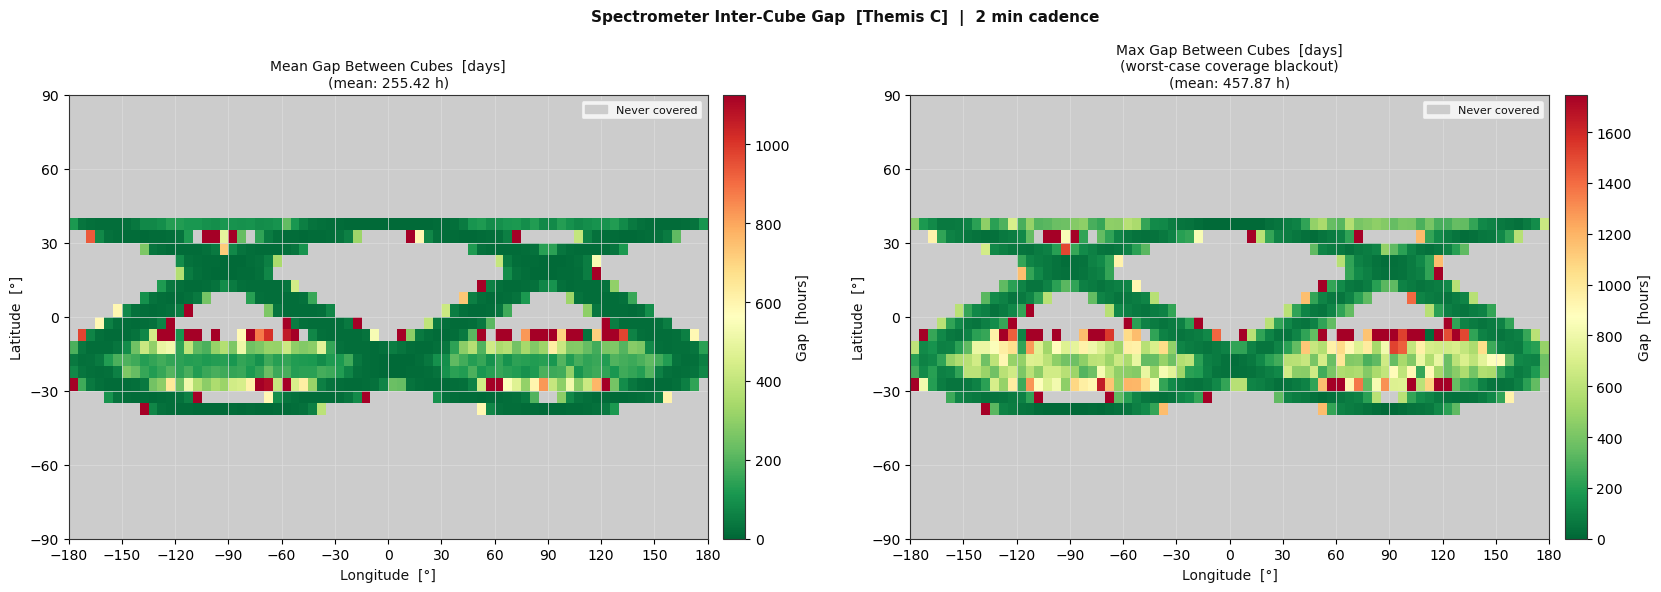

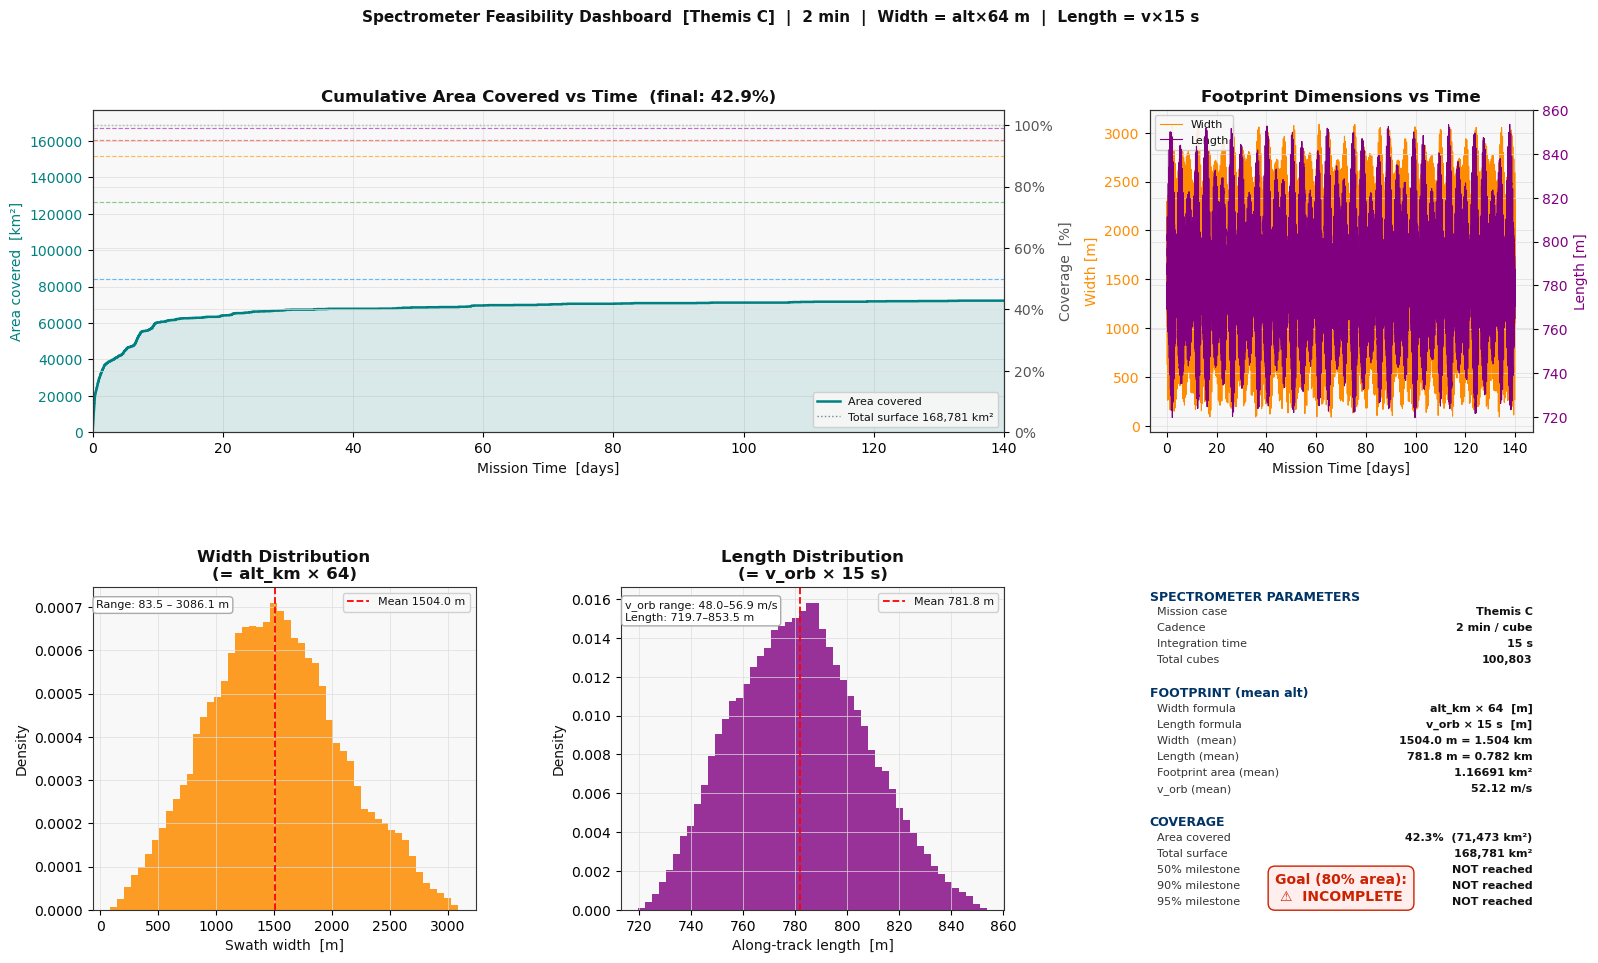

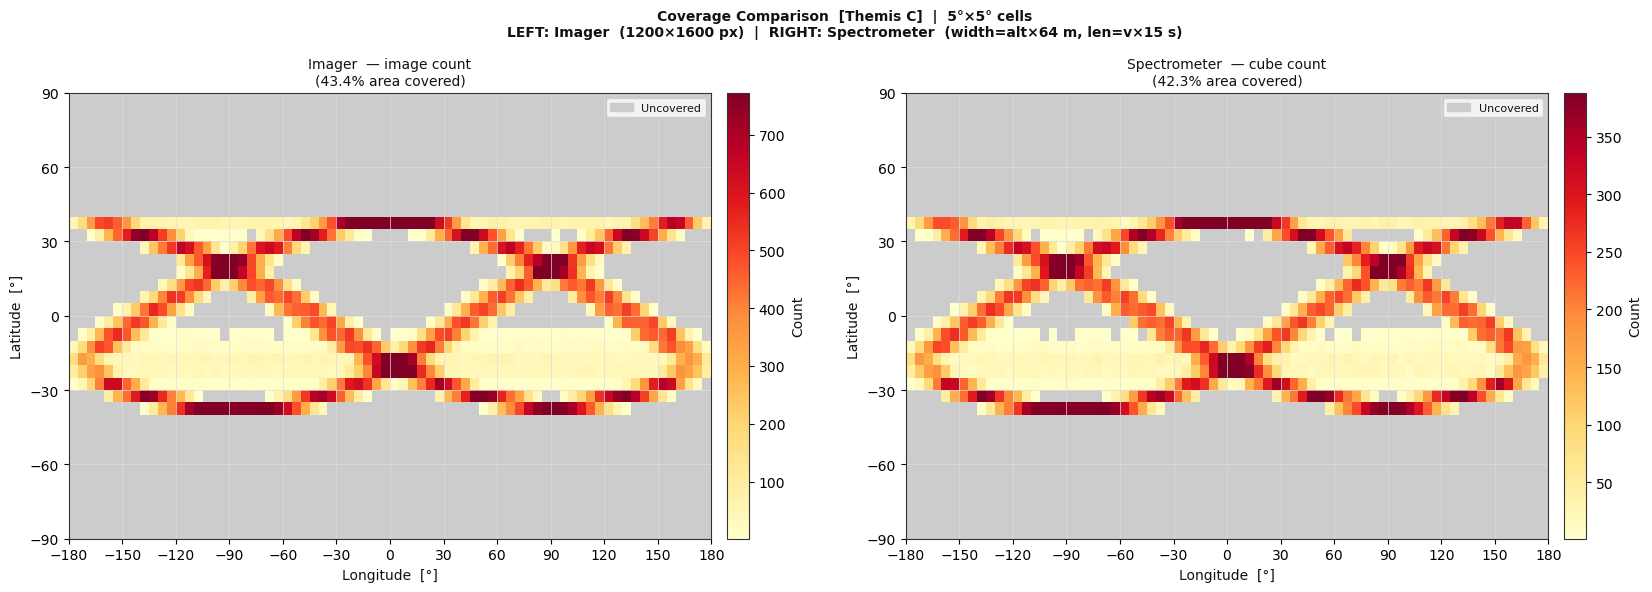


══════════════════════════════════════════════════════════════
  SPECTROMETER SUMMARY  [Themis C]
══════════════════════════════════════════════════════════════
  Footprint model    : Rectangle (along-track oriented)
  Width formula      : alt_km × 64  [m]
  Length formula     : v_orb × 15 s  [m]
  Cell credited if   : cell CENTRE inside rectangle
  Total cubes        : 100,803
  Orbital velocity   : 47.98 – 56.90 m/s  (mean 52.12)
  Width  range       : 83.5 – 3086.1 m
  Length range       : 719.7 – 853.5 m
  Footprint area     : 0.06682 – 2.25777 km²
  Area covered       : 42.3%  (71,473.3 km²)
  Coverage verdict   : INCOMPLETE ⚠
   50% milestone  : NOT reached
   75% milestone  : NOT reached
   90% milestone  : NOT reached
   95% milestone  : NOT reached
   99% milestone  : NOT reached
══════════════════════════════════════════════════════════════


In [20]:
"""
════════════════════════════════════════════════════════════════════════════════
  CELL 3 — SPECTROMETER  ·  RECTANGULAR FOOTPRINT COVERAGE
  ──────────────────────────────────────────────────────────────────────────────
  Paste as a NEW CELL after Cell 2 (imager cell).

  Instrument model  (Themis B — change variables below for other cases)
  ──────────────────────────────────────────────────────────────────────
    Sampling rate  :  2 min / cube
    Footprint shape:  Rectangle, oriented along ground track
    Width  [m]     =  altitude_km × 64           (cross-track, pushbroom)
    Length [m]     =  orbital_velocity [m/s] × 15 s  (along-track, integration time)

  Key difference from imager
  ──────────────────────────
    The along-track length is set by the INTEGRATION TIME (15 s) ×
    orbital velocity, NOT by pixel count × IFOV.  This reflects how a
    pushbroom spectrometer collects one spatial line per readout and
    builds up the "cube" length along the ground track during the
    15-second integration window.

  Orbital velocity source
  ───────────────────────
    Computed from the inertial state vector (vx,vy,vz in ECLIPJ2000)
    interpolated to each spectrometer epoch.
    v_orb = sqrt(vx² + vy² + vz²)   [m/s]

  Requires (already in scope)
  ───────────────────────────
    days, altitude_km, latitudes_rad, longitudes_rad
    states_arr  (cols 3-5 = vx,vy,vz)
    times_dv, times_state
    lat_edges, lon_edges, lat_centres, lon_centres, n_lat, n_lon
    cell_area_km2, total_surface_area_km2
    R_THEMIS_KM  (or R_THEMIS_KM_IMG from Cell 2)
    heading_img  (from Cell 2 — recomputed here if not available)
════════════════════════════════════════════════════════════════════════════════
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import defaultdict

# ════════════════════════════════════════════════════════════════════════════════
# 0.  MISSION / INSTRUMENT PARAMETERS  ← change here for different cases
# ════════════════════════════════════════════════════════════════════════════════
MISSION_CASE_SPEC      = 'Themis C'       # label
SPEC_CADENCE_MIN       = 2.0              # minutes between cubes
SPEC_WIDTH_COEFF       = 64.0            # width [m] = alt_km × this coefficient
SPEC_INTEGRATION_S     = 15.0            # along-track integration time [s]
COVERAGE_GOAL_SPEC_PCT = 80.0            # feasibility threshold [%]
R_SPEC_KM              = 115.893         # mean radius [km] (same as before)

# ════════════════════════════════════════════════════════════════════════════════
# 1.  GRID  (re-use from earlier cells)
# ════════════════════════════════════════════════════════════════════════════════
try:
    _ = lat_edges
except NameError:
    _BD = 5.0
    lat_edges   = np.arange(-90,   90  + _BD, _BD)
    lon_edges   = np.arange(-180,  180 + _BD, _BD)
    lat_centres = 0.5*(lat_edges[:-1] + lat_edges[1:])
    lon_centres = 0.5*(lon_edges[:-1] + lon_edges[1:])
    n_lat = len(lat_centres); n_lon = len(lon_centres)

try:
    _ = cell_area_km2
except NameError:
    _dlon_r = np.deg2rad(5.0)
    cell_area_km2 = np.zeros((n_lat, n_lon))
    for _ii, (_ls, _ln) in enumerate(zip(lat_edges[:-1], lat_edges[1:])):
        cell_area_km2[_ii, :] = (R_SPEC_KM**2 * _dlon_r
                                  * (np.sin(np.deg2rad(_ln))
                                     - np.sin(np.deg2rad(_ls))))
    total_surface_area_km2 = cell_area_km2.sum()

_lat_c_r = np.deg2rad(lat_centres)
_lon_c_r = np.deg2rad(lon_centres)
print(f"Total surface area: {total_surface_area_km2:.1f} km²")

# ════════════════════════════════════════════════════════════════════════════════
# 2.  SPECTROMETER EPOCH TIMELINE  (uniform 2-min cadence)
# ════════════════════════════════════════════════════════════════════════════════
_SPEC_CADENCE_S = SPEC_CADENCE_MIN * 60.0
_times_s_full   = (days - days[0]) * 86400.0

t_spec_s    = np.arange(0, _times_s_full[-1], _SPEC_CADENCE_S)
t_spec_d    = t_spec_s / 86400.0
N_spec      = len(t_spec_s)

# Interpolate altitude and nadir lat/lon
alt_spec     = np.interp(t_spec_s, _times_s_full, altitude_km)      # km
lat_spec_r   = np.interp(t_spec_s, _times_s_full, latitudes_rad)    # rad
lon_spec_r   = np.interp(t_spec_s, _times_s_full, longitudes_rad)   # rad
lat_spec_deg = np.rad2deg(lat_spec_r)
lon_spec_deg = np.rad2deg(lon_spec_r)

# ── Orbital velocity at each cube epoch ─────────────────────────────────────
# Inertial speed = |v| where states_arr[:,3:6] = vx,vy,vz
_vx_full = np.interp(_times_s_full, _times_s_full, states_arr[:, 3])
_vy_full = np.interp(_times_s_full, _times_s_full, states_arr[:, 4])
_vz_full = np.interp(_times_s_full, _times_s_full, states_arr[:, 5])
_v_full  = np.sqrt(_vx_full**2 + _vy_full**2 + _vz_full**2)

vx_spec  = np.interp(t_spec_s, _times_s_full, states_arr[:, 3])
vy_spec  = np.interp(t_spec_s, _times_s_full, states_arr[:, 4])
vz_spec  = np.interp(t_spec_s, _times_s_full, states_arr[:, 5])
v_orb_spec = np.sqrt(vx_spec**2 + vy_spec**2 + vz_spec**2)   # [m/s]

print(f"Spectrometer cubes ({SPEC_CADENCE_MIN:.0f} min cadence): {N_spec:,}")
print(f"Orbital velocity range: {v_orb_spec.min():.2f} – {v_orb_spec.max():.2f} m/s  "
      f"(mean {v_orb_spec.mean():.2f} m/s)")

# ════════════════════════════════════════════════════════════════════════════════
# 3.  SPECTROMETER FOOTPRINT DIMENSIONS AT EACH CUBE EPOCH
# ════════════════════════════════════════════════════════════════════════════════
spec_width_m   = SPEC_WIDTH_COEFF * alt_spec              # [m]  cross-track
spec_length_m  = v_orb_spec * SPEC_INTEGRATION_S          # [m]  along-track
spec_width_km  = spec_width_m  / 1e3                      # [km]
spec_length_km = spec_length_m / 1e3                      # [km]
spec_area_km2  = spec_width_km * spec_length_km            # [km²]

print(f"\n── Spectrometer footprint at mean altitude ({alt_spec.mean():.1f} km) ──────")
print(f"  Width  (cross-track) : {spec_width_m.mean():.1f} m  "
      f"= {spec_width_km.mean():.3f} km  (= alt_km × {SPEC_WIDTH_COEFF:.0f})")
print(f"  Length (along-track) : {spec_length_m.mean():.1f} m  "
      f"= {spec_length_km.mean():.3f} km  (= v_orb × {SPEC_INTEGRATION_S:.0f} s)")
print(f"  Footprint area       : {spec_area_km2.mean():.4f} km²")

# ════════════════════════════════════════════════════════════════════════════════
# 4.  GROUND-TRACK HEADING AT EACH CUBE EPOCH
# ════════════════════════════════════════════════════════════════════════════════
def _compute_headings(lat_r, lon_r):
    dlat = np.gradient(lat_r)
    dlon = np.gradient(lon_r)
    return np.arctan2(dlon * np.cos(lat_r), dlat)

heading_spec = _compute_headings(lat_spec_r, lon_spec_r)

# ════════════════════════════════════════════════════════════════════════════════
# 5.  RECTANGULAR FOOTPRINT CELL CHECK
# ════════════════════════════════════════════════════════════════════════════════
spec_count_map  = np.zeros((n_lat, n_lon), dtype=np.int32)
spec_width_best = np.full((n_lat, n_lon), np.nan)    # best (narrowest) width [m]

_half_len_s = spec_length_km / 2.0   # (N_spec,) along-track half-length [km]
_half_wid_s = spec_width_km  / 2.0   # (N_spec,) cross-track half-width  [km]

print(f"\nComputing spectrometer rectangular coverage … ({N_spec:,} cubes × {n_lat}×{n_lon} cells)")
print("(this may take 30–90 s)")
_lat_e_r = np.deg2rad(lat_edges)
_lon_e_r = np.deg2rad(lon_edges)
for k in range(N_spec):
    _lat0 = lat_spec_r[k]
    _lon0 = lon_spec_r[k]
    _h    = heading_spec[k]
    _hl   = _half_len_s[k]
    _hw   = _half_wid_s[k]
    sh, ch = np.sin(_h), np.cos(_h)

    # ── (A) CENTRE CHECK ─────────────────────────────────────────────────────
    dN_c = R_SPEC_KM * (_lat_c_r - _lat0)
    dE_c = R_SPEC_KM * np.cos(_lat0) * (_lon_c_r - _lon0)
    along_c = dE_c[np.newaxis, :] * sh + dN_c[:, np.newaxis] * ch
    cross_c = dE_c[np.newaxis, :] * ch - dN_c[:, np.newaxis] * sh
    centre_inside = (np.abs(along_c) <= _hl) & (np.abs(cross_c) <= _hw)

    # ── (B) MAXIMUM OVERLAP CELL ─────────────────────────────────────────────
    dN_e = R_SPEC_KM * (_lat_e_r - _lat0)
    dE_e = R_SPEC_KM * np.cos(_lat0) * (_lon_e_r - _lon0)
    along_e = dE_e[np.newaxis, :] * sh + dN_e[:, np.newaxis] * ch
    cross_e = dE_e[np.newaxis, :] * ch - dN_e[:, np.newaxis] * sh

    along_min = np.minimum(np.minimum(along_e[:-1, :-1], along_e[1:, :-1]),
                           np.minimum(along_e[:-1,  1:], along_e[1:,  1:]))
    along_max = np.maximum(np.maximum(along_e[:-1, :-1], along_e[1:, :-1]),
                           np.maximum(along_e[:-1,  1:], along_e[1:,  1:]))
    cross_min = np.minimum(np.minimum(cross_e[:-1, :-1], cross_e[1:, :-1]),
                           np.minimum(cross_e[:-1,  1:], cross_e[1:,  1:]))
    cross_max = np.maximum(np.maximum(cross_e[:-1, :-1], cross_e[1:, :-1]),
                           np.maximum(cross_e[:-1,  1:], cross_e[1:,  1:]))

    inter_along = np.maximum(0.0, np.minimum(along_max, _hl) - np.maximum(along_min, -_hl))
    inter_cross = np.maximum(0.0, np.minimum(cross_max, _hw) - np.maximum(cross_min, -_hw))
    intersection_area = inter_along * inter_cross

    max_overlap_cell = np.zeros((n_lat, n_lon), dtype=bool)
    best_flat = np.argmax(intersection_area)
    if intersection_area.ravel()[best_flat] > 0.0:
        max_overlap_cell[np.unravel_index(best_flat, (n_lat, n_lon))] = True

    inside = centre_inside | max_overlap_cell

    spec_count_map[inside] += 1
    _w = spec_width_m[k]
    spec_width_best[inside] = np.where(
        np.isnan(spec_width_best[inside]) | (_w < spec_width_best[inside]),
        _w, spec_width_best[inside])
print("Done.")

# ════════════════════════════════════════════════════════════════════════════════
# 6.  INTER-CUBE GAP PER CELL
# ════════════════════════════════════════════════════════════════════════════════
lat_spec_idx = np.clip(np.searchsorted(lat_edges[1:], lat_spec_deg), 0, n_lat-1)
lon_spec_idx = np.clip(np.searchsorted(lon_edges[1:], lon_spec_deg), 0, n_lon-1)

cell_spec_times  = defaultdict(list)
for k in range(N_spec):
    cell_spec_times[(lat_spec_idx[k], lon_spec_idx[k])].append(t_spec_d[k])

mean_spec_gap_d = np.full((n_lat, n_lon), np.nan)
max_spec_gap_d  = np.full((n_lat, n_lon), np.nan)
for (i, j), _tlist in cell_spec_times.items():
    _ts = sorted(_tlist)
    if len(_ts) > 1:
        _g = np.diff(_ts)
        mean_spec_gap_d[i, j] = _g.mean()
        max_spec_gap_d[i, j]  = _g.max()
    else:
        mean_spec_gap_d[i, j] = t_spec_d[-1]
        max_spec_gap_d[i, j]  = t_spec_d[-1]

# ════════════════════════════════════════════════════════════════════════════════
# 7.  COVERAGE STATISTICS  (area-weighted)
# ════════════════════════════════════════════════════════════════════════════════
covered_spec_pct  = (np.sum(cell_area_km2 * (spec_count_map > 0))
                     / total_surface_area_km2 * 100.0)
covered_spec_km2  = total_surface_area_km2 * covered_spec_pct / 100.0
cells_spec        = int((spec_count_map > 0).sum())

# Cumulative area vs time
_spec_seen   = set()
_spec_cum    = np.zeros(N_spec)
_spec_run    = 0.0
for k in range(N_spec):
    _c = (lat_spec_idx[k], lon_spec_idx[k])
    if _c not in _spec_seen:
        _spec_seen.add(_c)
        _spec_run += cell_area_km2[_c[0], _c[1]]
    _spec_cum[k] = _spec_run
_spec_cum_pct = _spec_cum / total_surface_area_km2 * 100.0

spec_thresh_days = {}
for _th in [50, 75, 90, 95, 99]:
    _idx = np.where(_spec_cum_pct >= _th)[0]
    spec_thresh_days[_th] = t_spec_d[_idx[0]] if len(_idx) else np.nan

print(f"\n── Spectrometer coverage summary ──────────────────────────────────────")
print(f"  Cells covered : {cells_spec} / {n_lat*n_lon}  ({covered_spec_pct:.1f}%)")
print(f"  Area covered  : {covered_spec_km2:,.1f} km² / {total_surface_area_km2:,.1f} km²")
for _th in [50, 75, 90, 95, 99]:
    _d = spec_thresh_days[_th]
    print(f"  {_th:>3}% area  :  {'day '+f'{_d:.1f}' if not np.isnan(_d) else 'NOT reached'}")

# ════════════════════════════════════════════════════════════════════════════════
# 8.  PLOTS
# ════════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f8',
    'axes.edgecolor': '#333',    'axes.labelcolor': '#111',
    'axes.grid': True,           'grid.color': '#dddddd',
    'grid.linewidth': 0.5,       'font.size': 10, 'text.color': '#111',
})

# ── Figure SPEC-1  :  Cube count map + best width map ────────────────────────
fig_s1, axes_s1 = plt.subplots(1, 2, figsize=(17, 6))
fig_s1.suptitle(
    f'Spectrometer Coverage Map  [{MISSION_CASE_SPEC}]  |  {SPEC_CADENCE_MIN:.0f} min cadence\n'
    f'Width = alt_km × {SPEC_WIDTH_COEFF:.0f} m  |  '
    f'Length = v_orb × {SPEC_INTEGRATION_S:.0f} s  |  5°×5° cells',
    fontsize=10, fontweight='bold')

ax = axes_s1[0]
_sm = np.ma.masked_equal(spec_count_map, 0)
im_s0 = ax.pcolormesh(lon_edges, lat_edges, _sm,
                       cmap='YlGnBu', shading='flat', vmin=1)
ax.pcolormesh(lon_edges, lat_edges,
              np.ma.masked_where(spec_count_map > 0, np.ones((n_lat, n_lon))),
              cmap=mcolors.ListedColormap(['#cccccc']), shading='flat',
              vmin=0.5, vmax=1.5)
_st = max(1, N_spec // 2000)
ax.scatter(lon_spec_deg[::_st], lat_spec_deg[::_st],
           s=0.4, c='black', alpha=0.2, zorder=4)
cbar_s0 = fig_s1.colorbar(im_s0, ax=ax, pad=0.02)
cbar_s0.set_label('# cubes  (cell centre inside rectangle)')
ax.set_title(f'Cube Count per Cell\n'
             f'(grey = uncovered  |  {covered_spec_pct:.1f}% area  |  '
             f'{cells_spec}/{n_lat*n_lon} cells)', fontsize=10)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30)); ax.set_yticks(np.arange(-90, 91, 30))
ax.set_xlabel('Longitude  [°]'); ax.set_ylabel('Latitude  [°]')
ax.legend(handles=[mpatches.Patch(color='#cccccc', label='Uncovered cell')],
          fontsize=8, loc='upper right')

ax = axes_s1[1]
_wm = np.ma.masked_invalid(spec_width_best)
im_s1 = ax.pcolormesh(lon_edges, lat_edges, _wm,
                       cmap='RdYlGn_r', shading='flat',
                       vmin=np.nanpercentile(spec_width_best, 5),
                       vmax=np.nanpercentile(spec_width_best, 95))
ax.pcolormesh(lon_edges, lat_edges,
              np.ma.masked_where(~np.isnan(spec_width_best), np.ones((n_lat, n_lon))),
              cmap=mcolors.ListedColormap(['#cccccc']), shading='flat',
              vmin=0.5, vmax=1.5)
cbar_s1 = fig_s1.colorbar(im_s1, ax=ax, pad=0.02)
cbar_s1.set_label('Best (narrowest) swath width achieved  [m]')
ax.set_title(f'Best Swath Width per Cell\n'
             f'(narrower = lower altitude = better SNR)',
             fontsize=10)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30)); ax.set_yticks(np.arange(-90, 91, 30))
ax.set_xlabel('Longitude  [°]'); ax.set_ylabel('Latitude  [°]')

plt.tight_layout()
plt.savefig('figSPEC1_coverage_map.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure SPEC-2  :  Gap maps ───────────────────────────────────────────────
fig_s2, axes_s2 = plt.subplots(1, 2, figsize=(17, 6))
fig_s2.suptitle(
    f'Spectrometer Inter-Cube Gap  [{MISSION_CASE_SPEC}]  |  '
    f'{SPEC_CADENCE_MIN:.0f} min cadence',
    fontsize=11, fontweight='bold')

_valid_s = ~np.isnan(mean_spec_gap_d)
for ax, _data, _title in zip(
        axes_s2,
        [mean_spec_gap_d, max_spec_gap_d],
        ['Mean Gap Between Cubes  [days]',
         'Max Gap Between Cubes  [days]\n(worst-case coverage blackout)']):
    _dh = _data * 24.0
    _vmax_h = np.nanpercentile(_dh[_valid_s], 95)
    im = ax.pcolormesh(lon_edges, lat_edges, np.ma.masked_invalid(_dh),
                       cmap='RdYlGn_r', shading='flat', vmin=0, vmax=_vmax_h)
    ax.pcolormesh(lon_edges, lat_edges,
                  np.ma.masked_where(_valid_s, np.ones((n_lat, n_lon))),
                  cmap=mcolors.ListedColormap(['#cccccc']), shading='flat',
                  vmin=0.5, vmax=1.5)
    cbar = fig_s2.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label('Gap  [hours]')
    ax.set_title(f'{_title}\n(mean: {np.nanmean(_dh):.2f} h)', fontsize=10)
    ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.set_xticks(np.arange(-180, 181, 30)); ax.set_yticks(np.arange(-90, 91, 30))
    ax.set_xlabel('Longitude  [°]'); ax.set_ylabel('Latitude  [°]')
    ax.legend(handles=[mpatches.Patch(color='#cccccc', label='Never covered')],
              fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('figSPEC2_gap_maps.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure SPEC-3  :  Timeline + dashboard ───────────────────────────────────
fig_s3 = plt.figure(figsize=(16, 10))
fig_s3.suptitle(
    f'Spectrometer Feasibility Dashboard  [{MISSION_CASE_SPEC}]  |  '
    f'{SPEC_CADENCE_MIN:.0f} min  |  '
    f'Width = alt×{SPEC_WIDTH_COEFF:.0f} m  |  Length = v×{SPEC_INTEGRATION_S:.0f} s',
    fontsize=11, fontweight='bold')

gs_s3 = GridSpec(2, 3, figure=fig_s3, wspace=0.38, hspace=0.48,
                 left=0.07, right=0.97, top=0.88, bottom=0.08)

# S-0  Cumulative area covered
ax      = fig_s3.add_subplot(gs_s3[0, :2])
ax2_pct = ax.twinx()
ax.plot(t_spec_d, _spec_cum, color='teal', lw=1.8, label='Area covered', zorder=4)
ax.fill_between(t_spec_d, _spec_cum, alpha=0.12, color='teal', zorder=3)
ax.axhline(total_surface_area_km2, color='gray', ls=':', lw=1.0,
           label=f'Total surface {total_surface_area_km2:,.0f} km²')
ax.set_xlabel('Mission Time  [days]')
ax.set_ylabel('Area covered  [km²]', color='teal')
ax.tick_params(axis='y', labelcolor='teal')
ax.set_xlim(0, t_spec_d[-1]); ax.set_ylim(0, total_surface_area_km2 * 1.05)
ax2_pct.set_ylabel('Coverage  [%]', color='#555')
ax2_pct.tick_params(axis='y', labelcolor='#555')
ax2_pct.set_ylim(0, 105)
ax2_pct.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

_th_cols = {50:'#2196F3',75:'#4CAF50',90:'#FF9800',95:'#F44336',99:'#9C27B0'}
for _th, _col in _th_cols.items():
    _a_th = total_surface_area_km2 * _th / 100.0
    ax.axhline(_a_th, color=_col, ls='--', lw=0.85, alpha=0.65)
    _d = spec_thresh_days[_th]
    if not np.isnan(_d):
        ax.axvline(_d, color=_col, ls=':', lw=1.1, alpha=0.75)
        ax.annotate(f'{_th}%\nday {_d:.1f}',
                    xy=(_d, _a_th),
                    xytext=(_d + t_spec_d[-1]*0.015, _a_th + total_surface_area_km2*0.02),
                    fontsize=7, color=_col,
                    arrowprops=dict(arrowstyle='->', color=_col, lw=0.7))
ax.set_title(f'Cumulative Area Covered vs Time  '
             f'(final: {_spec_cum_pct[-1]:.1f}%)', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

# S-1  Footprint dimensions vs time (timeline)
ax = fig_s3.add_subplot(gs_s3[0, 2])
ax2 = ax.twinx()
ax.plot(t_spec_d, spec_width_m,  color='darkorange', lw=0.8, label='Width')
ax2.plot(t_spec_d, spec_length_m, color='purple',    lw=0.8, label='Length')
ax.set_ylabel('Width [m]',  color='darkorange'); ax.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylabel('Length [m]', color='purple');   ax2.tick_params(axis='y', labelcolor='purple')
ax.set_xlabel('Mission Time [days]')
ax.set_title('Footprint Dimensions vs Time', fontweight='bold')
lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, lbl1+lbl2, fontsize=8)

# S-2  Width distribution
ax = fig_s3.add_subplot(gs_s3[1, 0])
ax.hist(spec_width_m, bins=50, color='darkorange', edgecolor='none', alpha=0.85, density=True)
ax.axvline(spec_width_m.mean(), color='red', ls='--', lw=1.3,
           label=f'Mean {spec_width_m.mean():.1f} m')
ax.set_xlabel('Swath width  [m]'); ax.set_ylabel('Density')
ax.set_title(f'Width Distribution\n(= alt_km × {SPEC_WIDTH_COEFF:.0f})', fontweight='bold')
ax.legend(fontsize=8)
ax.text(0.01, 0.96, f'Range: {spec_width_m.min():.1f} – {spec_width_m.max():.1f} m',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(facecolor='white', edgecolor='#aaa', boxstyle='round,pad=0.3'))

# S-3  Length (along-track) distribution
ax = fig_s3.add_subplot(gs_s3[1, 1])
ax.hist(spec_length_m, bins=50, color='purple', edgecolor='none', alpha=0.80, density=True)
ax.axvline(spec_length_m.mean(), color='red', ls='--', lw=1.3,
           label=f'Mean {spec_length_m.mean():.1f} m')
ax.set_xlabel('Along-track length  [m]'); ax.set_ylabel('Density')
ax.set_title(f'Length Distribution\n(= v_orb × {SPEC_INTEGRATION_S:.0f} s)', fontweight='bold')
ax.legend(fontsize=8)
ax.text(0.01, 0.96,
        f'v_orb range: {v_orb_spec.min():.1f}–{v_orb_spec.max():.1f} m/s\n'
        f'Length: {spec_length_m.min():.1f}–{spec_length_m.max():.1f} m',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(facecolor='white', edgecolor='#aaa', boxstyle='round,pad=0.3'))

# S-4  Scorecard
ax = fig_s3.add_subplot(gs_s3[1, 2])
ax.axis('off')
_sc = [
    ('SPECTROMETER PARAMETERS',   ''),
    ('  Mission case',             MISSION_CASE_SPEC),
    ('  Cadence',                  f'{SPEC_CADENCE_MIN:.0f} min / cube'),
    ('  Integration time',         f'{SPEC_INTEGRATION_S:.0f} s'),
    ('  Total cubes',              f'{N_spec:,}'),
    ('',                           ''),
    ('FOOTPRINT (mean alt)',        ''),
    ('  Width formula',            f'alt_km × {SPEC_WIDTH_COEFF:.0f}  [m]'),
    ('  Length formula',           f'v_orb × {SPEC_INTEGRATION_S:.0f} s  [m]'),
    ('  Width  (mean)',            f'{spec_width_m.mean():.1f} m = {spec_width_km.mean():.3f} km'),
    ('  Length (mean)',            f'{spec_length_m.mean():.1f} m = {spec_length_km.mean():.3f} km'),
    ('  Footprint area (mean)',    f'{spec_area_km2.mean():.5f} km²'),
    ('  v_orb (mean)',             f'{v_orb_spec.mean():.2f} m/s'),
    ('',                           ''),
    ('COVERAGE',                   ''),
    ('  Area covered',             f'{covered_spec_pct:.1f}%  ({covered_spec_km2:,.0f} km²)'),
    ('  Total surface',            f'{total_surface_area_km2:,.0f} km²'),
    ('  50% milestone',            f'day {spec_thresh_days[50]:.1f}' if not np.isnan(spec_thresh_days[50]) else 'NOT reached'),
    ('  90% milestone',            f'day {spec_thresh_days[90]:.1f}' if not np.isnan(spec_thresh_days[90]) else 'NOT reached'),
    ('  95% milestone',            f'day {spec_thresh_days[95]:.1f}' if not np.isnan(spec_thresh_days[95]) else 'NOT reached'),
]
_y0 = 0.99
for _lbl, _val in _sc:
    if _val == '':
        ax.text(0.0, _y0, _lbl, fontsize=9, fontweight='bold', va='top',
                transform=ax.transAxes, color='#003366')
    else:
        ax.text(0.0, _y0, _lbl, fontsize=8, va='top',
                transform=ax.transAxes, color='#333')
        ax.text(1.0, _y0, _val, fontsize=8, va='top', ha='right',
                transform=ax.transAxes, color='#111', fontweight='bold')
    _y0 -= 0.050

_feasible_s = covered_spec_pct >= COVERAGE_GOAL_SPEC_PCT
_vcol  = '#1a7a1a' if _feasible_s else '#cc2200'
_vtxt  = '✓  FEASIBLE' if _feasible_s else '⚠  INCOMPLETE'
ax.text(0.5, 0.02, f'Goal ({COVERAGE_GOAL_SPEC_PCT:.0f}% area):\n{_vtxt}',
        ha='center', va='bottom', transform=ax.transAxes,
        fontsize=10, fontweight='bold', color=_vcol,
        bbox=dict(facecolor='#eeffee' if _feasible_s else '#ffeeee',
                  edgecolor=_vcol, boxstyle='round,pad=0.5'))

plt.savefig('figSPEC3_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure SPEC-4  :  Side-by-side comparison with imager ────────────────────
# (only shown if img_count_map exists from Cell 2)
try:
    fig_cmp, axes_cmp = plt.subplots(1, 2, figsize=(17, 6))
    fig_cmp.suptitle(
        f'Coverage Comparison  [{MISSION_CASE_SPEC}]  |  5°×5° cells\n'
        f'LEFT: Imager  ({IMG_PIX_CROSS}×{IMG_PIX_ALONG} px)  |  '
        f'RIGHT: Spectrometer  (width=alt×{SPEC_WIDTH_COEFF:.0f} m, '
        f'len=v×{SPEC_INTEGRATION_S:.0f} s)',
        fontsize=10, fontweight='bold')

    for ax, _cmap_data, _label in zip(
            axes_cmp,
            [img_count_map, spec_count_map],
            ['Imager  — image count', 'Spectrometer  — cube count']):
        _ma = np.ma.masked_equal(_cmap_data, 0)
        _vmax = np.percentile(_cmap_data[_cmap_data > 0], 95) if (_cmap_data > 0).any() else 1
        im_c = ax.pcolormesh(lon_edges, lat_edges, _ma,
                             cmap='YlOrRd', shading='flat', vmin=1, vmax=_vmax)
        ax.pcolormesh(lon_edges, lat_edges,
                      np.ma.masked_where(_cmap_data > 0, np.ones((n_lat, n_lon))),
                      cmap=mcolors.ListedColormap(['#cccccc']), shading='flat',
                      vmin=0.5, vmax=1.5)
        fig_cmp.colorbar(im_c, ax=ax, pad=0.02).set_label('Count')
        _pct = np.sum(cell_area_km2 * (_cmap_data > 0)) / total_surface_area_km2 * 100.0
        ax.set_title(f'{_label}\n({_pct:.1f}% area covered)', fontsize=10)
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
        ax.set_xticks(np.arange(-180, 181, 30)); ax.set_yticks(np.arange(-90, 91, 30))
        ax.set_xlabel('Longitude  [°]'); ax.set_ylabel('Latitude  [°]')
        ax.legend(handles=[mpatches.Patch(color='#cccccc', label='Uncovered')],
                  fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.savefig('figSPEC4_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
except NameError:
    print("Imager data (img_count_map) not in scope — skipping comparison plot.")
    print("Run Cell 2 first to enable this figure.")

# ════════════════════════════════════════════════════════════════════════════════
# 9.  PRINT FINAL SUMMARY
# ════════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*62}")
print(f"  SPECTROMETER SUMMARY  [{MISSION_CASE_SPEC}]")
print(f"{'═'*62}")
print(f"  Footprint model    : Rectangle (along-track oriented)")
print(f"  Width formula      : alt_km × {SPEC_WIDTH_COEFF:.0f}  [m]")
print(f"  Length formula     : v_orb × {SPEC_INTEGRATION_S:.0f} s  [m]")
print(f"  Cell credited if   : cell CENTRE inside rectangle")
print(f"  Total cubes        : {N_spec:,}")
print(f"  Orbital velocity   : {v_orb_spec.min():.2f} – {v_orb_spec.max():.2f} m/s  "
      f"(mean {v_orb_spec.mean():.2f})")
print(f"  Width  range       : {spec_width_m.min():.1f} – {spec_width_m.max():.1f} m")
print(f"  Length range       : {spec_length_m.min():.1f} – {spec_length_m.max():.1f} m")
print(f"  Footprint area     : {spec_area_km2.min():.5f} – {spec_area_km2.max():.5f} km²")
print(f"  Area covered       : {covered_spec_pct:.1f}%  ({covered_spec_km2:,.1f} km²)")
print(f"  Coverage verdict   : {'FEASIBLE ✓' if _feasible_s else 'INCOMPLETE ⚠'}")
for _th in [50, 75, 90, 95, 99]:
    _d = spec_thresh_days[_th]
    _s = f"day {_d:.1f}" if not np.isnan(_d) else "NOT reached"
    print(f"  {_th:>3}% milestone  : {_s}")
print(f"{'═'*62}")